# COLMAP + MASt3R Reconstruction

This notebook reconstructs a coral-reef transect (Israel-Eilat Sunrise) from two GoPro passes 
(forward + backward) using **MASt3R** features matched through **COLMAP**. 
After trying single-pass incremental mapping (Appendix A) and joint bundle adjustment (Appendix B), 
the approach that works is a **two-stage SIM3 merge**: reconstruct each pass independently with dense 
sequential pairs, then align them with a SIM3 transform estimated from cross-pass MASt3R pointmaps. 
Both passes achieve 100% registration with sub-pixel reprojection error.

## Setup

In [11]:
from pathlib import Path
import sys
import numpy as np

# Add mast3r repo to path so internal absolute imports work
MAST3R_REPO_PATH = Path("/home/hugues/Documents/mee-deepreefmap/mast3r")
if str(MAST3R_REPO_PATH) not in sys.path:
    sys.path.insert(0, str(MAST3R_REPO_PATH))

# dust3r is nested inside the mast3r submodule
DUST3R_PATH = MAST3R_REPO_PATH / "dust3r"
if str(DUST3R_PATH) not in sys.path:
    sys.path.insert(0, str(DUST3R_PATH))

# Add src to path for local imports
SRC_PATH = Path("/home/hugues/Documents/mee-deepreefmap/src")
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

In [2]:
"""Configure input/output paths.

Change these to point to your forward and backward reconstruction outputs.
"""
output_fw_dir = Path(
    "/home/hugues/Documents/mee-deepreefmap/output/exp_israel-eilat_fwbw_rec/2024_Sunrise_fw_leg"
)
output_bw_dir = Path(
    "/home/hugues/Documents/mee-deepreefmap/output/exp_israel-eilat_fwbw_rec/2024_Sunrise_bw_leg"
)
colmap_workdir = output_fw_dir.parent / "colmap_mast3r"
colmap_workdir.mkdir(parents=True, exist_ok=True)
print(f"COLMAP workdir: {colmap_workdir}")

COLMAP workdir: /home/hugues/Documents/mee-deepreefmap/output/exp_israel-eilat_fwbw_rec/colmap_mast3r


In [12]:
"""Load reconstruction outputs.

poses.npy         → [N, 4, 4] C2W poses
intrinsics.npy    → [N, 6] EUCM intrinsics (fx, fy, cx, cy, alpha, beta)
frames/*.jpg      → N frame images
"""
poses_fw = np.load(output_fw_dir / "poses.npy")
intrinsics_fw = np.load(output_fw_dir / "intrinsics.npy")
frames_fw = sorted(output_fw_dir.glob("frames/*.jpg"), key=lambda p: int(p.stem))

poses_bw = np.load(output_bw_dir / "poses.npy")
intrinsics_bw = np.load(output_bw_dir / "intrinsics.npy")
frames_bw = sorted(output_bw_dir.glob("frames/*.jpg"), key=lambda p: int(p.stem))

N_fw = len(frames_fw)
N_bw = len(frames_bw)
print(f"Forward:  {N_fw} frames, poses {poses_fw.shape}")
print(f"Backward: {N_bw} frames, poses {poses_bw.shape}")

Forward:  1160 frames, poses (1160, 4, 4)
Backward: 890 frames, poses (890, 4, 4)


In [13]:
"""Undistort all frames using EUCM → pinhole rectification.

GoPro Hero 10 uses a fisheye lens modeled by EUCM (Enhanced Unified Camera
Model) with params [fx, fy, cx, cy, alpha, beta]. COLMAP needs undistorted
images for PINHOLE camera model to work correctly.

The rectified images use [fx, fy, cx, cy] as pinhole intrinsics.
"""
import torch as _torch
from PIL import Image as _PIL
from sfm.inverse_warp import rectify_eucm
from tqdm import tqdm as _tqdm

rect_dir = colmap_workdir / "images_rect"
rect_dir.mkdir(exist_ok=True)

# Use mean intrinsics for rectification (they're nearly identical per frame)
_intr_mean = np.mean(intrinsics_fw, axis=0).astype(np.float32)  # [fx,fy,cx,cy,alpha,beta]
_intr_t = _torch.from_numpy(_intr_mean)


def _rectify_and_save(src_path, dst_path):
    if dst_path.exists():
        return
    pil = _PIL.open(src_path).convert("RGB")
    arr = np.array(pil).astype(np.float32) / 255.0
    H, W = arr.shape[:2]
    img_t = _torch.from_numpy(arr).permute(2, 0, 1).unsqueeze(0)  # [1, 3, H, W]
    mask_t = _torch.ones(1, 1, H, W)
    depth_t = _torch.ones(1, 1, H, W)
    rect_img, _, _ = rectify_eucm(img_t, mask_t, depth_t, _intr_t)
    rect_uint8 = (rect_img.transpose(1, 2, 0).clip(0, 1) * 255).astype(np.uint8)
    _PIL.fromarray(rect_uint8).save(dst_path, quality=95)


# Rectify all frames (indexed by position so rect_frames_fw[i] == rectified frames_fw[i])
rect_frames_fw = []
for p in _tqdm(frames_fw, desc="Rectifying fw"):
    dst = rect_dir / f"fwd_{int(p.stem):06d}.jpg"
    _rectify_and_save(p, dst)
    rect_frames_fw.append(dst)

rect_frames_bw = []
for p in _tqdm(frames_bw, desc="Rectifying bw"):
    dst = rect_dir / f"bwd_{int(p.stem):06d}.jpg"
    _rectify_and_save(p, dst)
    rect_frames_bw.append(dst)

# Pinhole intrinsics after rectification (just fx, fy, cx, cy — distortion removed)
pinhole_intr = _intr_mean[:4]
print(f"Rectified {len(rect_frames_fw)} fw + {len(rect_frames_bw)} bw frames → {rect_dir}")
print(
    f"Pinhole intrinsics: fx={pinhole_intr[0]:.1f} fy={pinhole_intr[1]:.1f} "
    f"cx={pinhole_intr[2]:.1f} cy={pinhole_intr[3]:.1f}"
)

Rectifying bw: 100%|██████████| 890/890 [00:00<00:00, 121867.73it/s]

Rectified 1160 fw + 890 bw frames → /home/hugues/Documents/mee-deepreefmap/output/exp_israel-eilat_fwbw_rec/colmap_mast3r/images_rect
Pinhole intrinsics: fx=365.4 fy=383.1 cx=319.8 cy=191.8


In [14]:
"""Load MASt3R model."""
import torch
from mast3r.model import AsymmetricMASt3R

model_name = "naver/MASt3R_ViTLarge_BaseDecoder_512_catmlpdpt_metric"
device = "cuda" if torch.cuda.is_available() else "cpu"
model = AsymmetricMASt3R.from_pretrained(model_name).to(device)
model.eval()
print(f"MASt3R loaded on {device}")

MASt3R loaded on cuda


In [6]:
"""Extract DINOv2 global descriptors for cross-view pair selection."""
import numpy as _np
import torchvision.transforms as _T
from PIL import Image as _PIL
from tqdm import tqdm as _tqdm

_device = "cuda" if torch.cuda.is_available() else "cpu"
_dino = torch.hub.load("facebookresearch/dinov2", "dinov2_vits14").to(_device).eval()
_transform = _T.Compose([
    _T.Resize(224, interpolation=_T.InterpolationMode.BICUBIC),
    _T.CenterCrop(224),
    _T.ToTensor(),
    _T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])


@torch.no_grad()
def _extract(paths, batch_size=32):
    descs = []
    for i in _tqdm(range(0, len(paths), batch_size), desc="DINOv2"):
        batch = torch.stack([
            _transform(_PIL.open(p).convert("RGB")) for p in paths[i : i + batch_size]
        ]).to(_device)
        descs.append(_dino(batch))
    return torch.cat(descs).cpu().numpy()


descs_fw = _extract(rect_frames_fw)
descs_bw = _extract(rect_frames_bw)
print(f"DINOv2 descriptors: fw {descs_fw.shape}, bw {descs_bw.shape}")

Using cache found in /home/hugues/.cache/torch/hub/facebookresearch_dinov2_main
/home/hugues/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:43: UserWarning: xFormers is available (SwiGLU)
  warnings.warn("xFormers is available (SwiGLU)")
/home/hugues/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:27: UserWarning: xFormers is available (Attention)
  warnings.warn("xFormers is available (Attention)")
/home/hugues/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:33: UserWarning: xFormers is available (Block)
  warnings.warn("xFormers is available (Block)")
DINOv2: 100%|██████████| 28/28 [00:11<00:00,  2.52it/s]

DINOv2 descriptors: fw (1160, 384), bw (890, 384)


Cross pairs (fw↔bw): 387
Sequential fw pairs: 921 (logwin offsets [5, 10, 20, 40])
Sequential bw pairs: 705 (logwin offsets [5, 10, 20, 40])


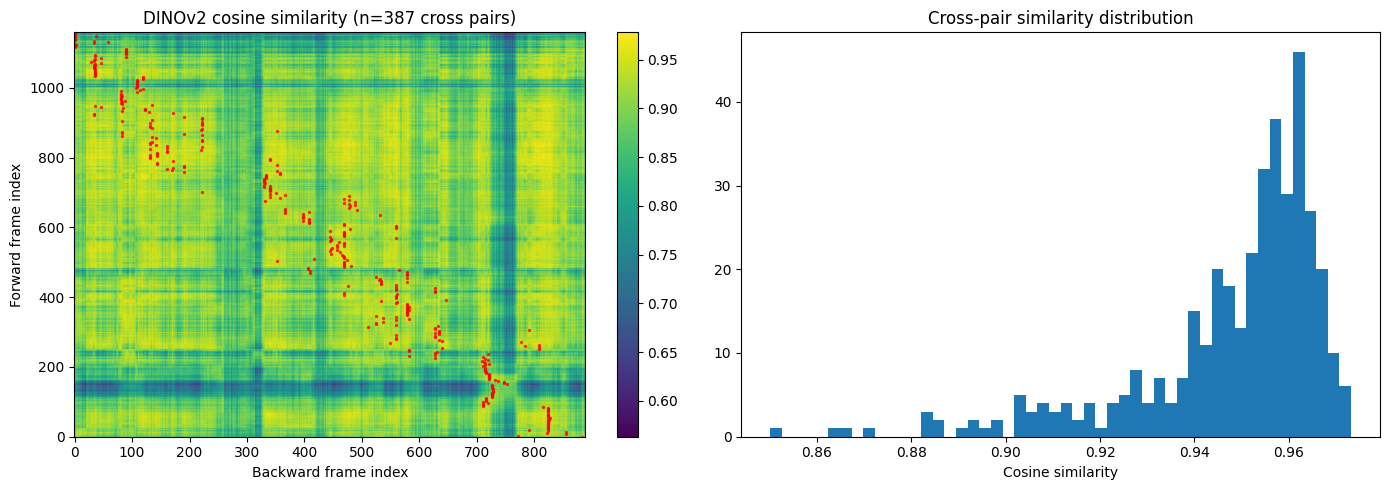

In [15]:
"""Select fw↔bw pairs using DINOv2 similarity + temporal prior.

Also select within-pass sequential pairs for COLMAP's sequential
connectivity. The combined pair list gives COLMAP both:
  - Sequential edges (odometry-like) within each pass
  - Cross-pass edges (loop closures) between fw and bw
"""
import matplotlib.pyplot as _plt

# ── Cross-pass pairs (fw ↔ bw) ──────────────────────────────────────
_norms_fw = np.linalg.norm(descs_fw, axis=1, keepdims=True)
_norms_bw = np.linalg.norm(descs_bw, axis=1, keepdims=True)
sim = (descs_fw / _norms_fw) @ (descs_bw / _norms_bw).T

FW_STEP = 3  # one cross pair every 3 fw frames (denser sampling)
WINDOW = 150  # search ±150 bw frames around time-prior center
SIM_THRESH = 0.85  # lower threshold to get more cross-pass pairs

cross_pairs_local = []  # (fw_local_idx, bw_local_idx)
for i in range(0, N_fw, FW_STEP):
    j_center = int(round((1 - i / max(N_fw - 1, 1)) * (N_bw - 1)))
    j_lo = max(0, j_center - WINDOW)
    j_hi = min(N_bw, j_center + WINDOW + 1)
    j_best = j_lo + int(np.argmax(sim[i, j_lo:j_hi]))
    if sim[i, j_best] >= SIM_THRESH:
        cross_pairs_local.append((i, j_best))

# ── Sequential pairs (logwin: connect at distances 5, 10, 20, 40) ──
# Close pairs give robust matches; distant pairs give parallax for triangulation.
# COLMAP needs wide-baseline pairs to bootstrap initialization.
LOGWIN_OFFSETS = [5, 10, 20, 40]

seq_fw_local = set()
for i in range(0, N_fw, 5):
    for off in LOGWIN_OFFSETS:
        j = min(i + off, N_fw - 1)
        if i != j:
            seq_fw_local.add((min(i, j), max(i, j)))
seq_fw_local = sorted(seq_fw_local)

seq_bw_local = set()
for i in range(0, N_bw, 5):
    for off in LOGWIN_OFFSETS:
        j = min(i + off, N_bw - 1)
        if i != j:
            seq_bw_local.add((min(i, j), max(i, j)))
seq_bw_local = sorted(seq_bw_local)

print(f"Cross pairs (fw↔bw): {len(cross_pairs_local)}")
print(f"Sequential fw pairs: {len(seq_fw_local)} (logwin offsets {LOGWIN_OFFSETS})")
print(f"Sequential bw pairs: {len(seq_bw_local)} (logwin offsets {LOGWIN_OFFSETS})")

# ── Visualisation ───────────────────────────────────────────────────
_fig, (_ax1, _ax2) = _plt.subplots(1, 2, figsize=(14, 5))
_ax1.imshow(sim, aspect="auto", origin="lower", cmap="viridis")
if cross_pairs_local:
    _fi_list, _bi_list = zip(*cross_pairs_local)
    _ax1.scatter(_bi_list, _fi_list, s=2, c="red", alpha=0.7)
_ax1.set_xlabel("Backward frame index")
_ax1.set_ylabel("Forward frame index")
_ax1.set_title(f"DINOv2 cosine similarity (n={len(cross_pairs_local)} cross pairs)")
_plt.colorbar(_ax1.images[0], ax=_ax1)

_sims = [float(sim[i, j]) for i, j in cross_pairs_local]
_ax2.hist(_sims, bins=50)
_ax2.set_xlabel("Cosine similarity")
_ax2.set_title("Cross-pair similarity distribution")
_plt.tight_layout()
_plt.show()

## Two-Stage SIM3 Reconstruction

The single-pass incremental mapping (Appendix A) produces two geometrically decoupled 
trajectories (1.7% shared 3D points between fw and bw). Root cause: COLMAP's 
incremental mapper builds one pass first, then can't effectively couple the 
second pass via the weak cross-pass matches.

**Strategy:**
1. Reconstruct fw and bw **independently** with dense sequential pairs
2. Estimate **SIM3** alignment between the two models using cross-pass MASt3R 
pointmaps projected through COLMAP-optimized poses
3. **Merge** the aligned models

### Stage 1 — Per-pass COLMAP with dense sequential pairs

Build separate COLMAP databases and run incremental mapping for fw and bw
independently. Dense short-range pairs (offsets 1, 2, 3) maintain chain
connectivity through the sandy low-texture section. Wide pairs (10, 20, 40)
provide triangulation parallax.

In [16]:
"""Stage 1a: Build dense sequential pair lists for each pass.

Offsets 1-3 give chain rigidity; 10, 20, 40 give triangulation parallax.
Every frame participates (step=1 for short-range, step=5 for wide-range).
"""
DENSE_OFFSETS = [1, 2, 3]
WIDE_OFFSETS = [10, 20, 40]


def _build_seq_pairs(n_frames, dense_offsets, wide_offsets):
    pairs = set()
    for i in range(n_frames):
        for off in dense_offsets:
            j = i + off
            if 0 <= j < n_frames:
                pairs.add((min(i, j), max(i, j)))
    for i in range(0, n_frames, 5):
        for off in wide_offsets:
            j = min(i + off, n_frames - 1)
            if i != j:
                pairs.add((min(i, j), max(i, j)))
    return sorted(pairs)


seq_fw_dense = _build_seq_pairs(N_fw, DENSE_OFFSETS, WIDE_OFFSETS)
seq_bw_dense = _build_seq_pairs(N_bw, DENSE_OFFSETS, WIDE_OFFSETS)

print(f"Dense sequential pairs:  fw={len(seq_fw_dense)}  bw={len(seq_bw_dense)}")
print(f"  (vs original sparse:  fw={len(seq_fw_local)}  bw={len(seq_bw_local)})")
print(f"Cross-pass pairs (unchanged): {len(cross_pairs_local)}")

Dense sequential pairs:  fw=4164  bw=3192
  (vs original sparse:  fw=921  bw=705)
Cross-pass pairs (unchanged): 387


In [17]:
"""Reload from disk — skip Stage 1b+1c after a kernel restart.

Re-imports modules, re-defines helper functions and constants that later cells
need, and reloads the per-pass COLMAP reconstructions from disk.
Run this INSTEAD of cells 1b and 1c.
"""
import sqlite3
import shutil
import pycolmap
import torchvision.transforms as _T
from PIL import Image as _PIL
from scipy.spatial.transform import Rotation as _Rot
from tqdm import tqdm as _tqdm

from dust3r.inference import inference as dust3r_inference
from mast3r.fast_nn import extract_correspondences_nonsym

TARGET_SIZE = 512
BATCH_SIZE = 4
CONF_THR = 1.5
SUBSAMPLE = 8
_ImgNorm = _T.Compose([_T.ToTensor(), _T.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])])


def _load_view_for_mast3r(global_idx):
    is_bw = global_idx >= N_fw
    local_idx = global_idx - N_fw if is_bw else global_idx
    path = frames_bw[local_idx] if is_bw else frames_fw[local_idx]
    pil = _PIL.open(path).convert("RGB")
    W, H = pil.size
    scale = TARGET_SIZE / max(H, W)
    new_H = round(H * scale / 16) * 16
    new_W = round(W * scale / 16) * 16
    pil = pil.resize((new_W, new_H), _PIL.Resampling.LANCZOS)
    return (
        dict(
            img=_ImgNorm(pil)[None],
            true_shape=np.int32([[new_H, new_W]]),
            idx=global_idx,
            instance=str(global_idx),
        ),
        new_H,
        new_W,
    )


fw_dir = colmap_workdir / "twostage_fw"
bw_dir = colmap_workdir / "twostage_bw"
fw_db = fw_dir / "colmap.db"
bw_db = bw_dir / "colmap.db"

assert fw_db.exists(), f"FW database not found: {fw_db}"
assert bw_db.exists(), f"BW database not found: {bw_db}"

fw_sparse = sorted(
    [d for d in (fw_dir / "sparse").iterdir() if d.is_dir() and d.name.isdigit()],
    key=lambda p: int(p.name),
)
bw_sparse = sorted(
    [d for d in (bw_dir / "sparse").iterdir() if d.is_dir() and d.name.isdigit()],
    key=lambda p: int(p.name),
)

rec_fw = pycolmap.Reconstruction(str(fw_sparse[0]))
rec_bw = pycolmap.Reconstruction(str(bw_sparse[0]))

print(
    f"Reloaded fw: {rec_fw.num_reg_images()} images, {rec_fw.num_points3D()} pts, reproj {rec_fw.compute_mean_reprojection_error():.3f} px"
)
print(
    f"Reloaded bw: {rec_bw.num_reg_images()} images, {rec_bw.num_points3D()} pts, reproj {rec_bw.compute_mean_reprojection_error():.3f} px"
)

Reloaded fw: 1160 images, 1663528 pts, reproj 0.852 px
Reloaded bw: 890 images, 1637761 pts, reproj 0.827 px


In [ ]:
"""Stage 1b: Create per-pass COLMAP databases + run MASt3R matching.

Each pass gets its own DB with dense sequential pairs. We reuse the existing
MASt3R model, rectified images, and EUCM→pinhole transform from earlier cells.
"""
import sqlite3
import shutil
import pycolmap
import torchvision.transforms as _T
from PIL import Image as _PIL
from scipy.spatial.transform import Rotation as _Rot
from tqdm import tqdm as _tqdm

from dust3r.inference import inference as dust3r_inference
from mast3r.fast_nn import extract_correspondences_nonsym

TARGET_SIZE = 512
BATCH_SIZE = 4
CONF_THR = 1.5
SUBSAMPLE = 8
_ImgNorm = _T.Compose([_T.ToTensor(), _T.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])])


def _load_view_for_mast3r(global_idx):
    is_bw = global_idx >= N_fw
    local_idx = global_idx - N_fw if is_bw else global_idx
    path = frames_bw[local_idx] if is_bw else frames_fw[local_idx]
    pil = _PIL.open(path).convert("RGB")
    W, H = pil.size
    scale = TARGET_SIZE / max(H, W)
    new_H = round(H * scale / 16) * 16
    new_W = round(W * scale / 16) * 16
    pil = pil.resize((new_W, new_H), _PIL.Resampling.LANCZOS)
    return (
        dict(
            img=_ImgNorm(pil)[None],
            true_shape=np.int32([[new_H, new_W]]),
            idx=global_idx,
            instance=str(global_idx),
        ),
        new_H,
        new_W,
    )


def _build_pass_db(pass_name, seq_pairs_local, frame_indices, poses, global_offset):
    """Build a COLMAP DB for a single pass, run MASt3R matching, return db_path."""
    pass_dir = colmap_workdir / f"twostage_{pass_name}"
    pass_dir.mkdir(parents=True, exist_ok=True)
    _db_path = pass_dir / "colmap.db"
    if _db_path.exists():
        _db_path.unlink()

    con = sqlite3.connect(str(_db_path))
    cur = con.cursor()
    cur.executescript("""
        CREATE TABLE IF NOT EXISTS cameras (
            camera_id INTEGER PRIMARY KEY AUTOINCREMENT NOT NULL,
            model INTEGER NOT NULL, width INTEGER NOT NULL,
            height INTEGER NOT NULL, params BLOB,
            prior_focal_length INTEGER NOT NULL);
        CREATE TABLE IF NOT EXISTS images (
            image_id INTEGER PRIMARY KEY AUTOINCREMENT NOT NULL,
            name TEXT NOT NULL UNIQUE, camera_id INTEGER NOT NULL,
            prior_qw REAL, prior_qx REAL, prior_qy REAL, prior_qz REAL,
            prior_tx REAL, prior_ty REAL, prior_tz REAL);
        CREATE TABLE IF NOT EXISTS keypoints (
            image_id INTEGER PRIMARY KEY NOT NULL,
            rows INTEGER NOT NULL, cols INTEGER NOT NULL, data BLOB);
        CREATE TABLE IF NOT EXISTS matches (
            pair_id INTEGER PRIMARY KEY NOT NULL,
            rows INTEGER NOT NULL, cols INTEGER NOT NULL, data BLOB);
        CREATE TABLE IF NOT EXISTS two_view_geometries (
            pair_id INTEGER PRIMARY KEY NOT NULL,
            rows INTEGER NOT NULL, cols INTEGER NOT NULL, data BLOB,
            config INTEGER NOT NULL,
            F BLOB, E BLOB, H BLOB, qvec BLOB, tvec BLOB);
    """)
    con.commit()

    W_orig, H_orig = _PIL.open(frames_fw[0]).size
    cam_params = np.array([_fx, _fy, _cx, _cy], dtype=np.float64)
    cur.execute(
        "INSERT INTO cameras (model, width, height, params, prior_focal_length) VALUES (?,?,?,?,?)",
        (1, W_orig, H_orig, cam_params.tobytes(), 1),
    )
    con.commit()
    camera_id = cur.lastrowid

    local_to_colmap_imid = {}
    used_local = set()
    for i, j in seq_pairs_local:
        used_local.add(i)
        used_local.add(j)

    prefix = "fwd" if pass_name == "fw" else "bwd"
    for li in sorted(used_local):
        c2w = poses[li]
        w2c = np.linalg.inv(c2w)
        qxyz = _Rot.from_matrix(w2c[:3, :3]).as_quat()
        qvec = [float(qxyz[3]), float(qxyz[0]), float(qxyz[1]), float(qxyz[2])]
        name = f"{prefix}_{li:06d}.jpg"
        cur.execute(
            "INSERT INTO images (name, camera_id, prior_qw, prior_qx, prior_qy, prior_qz, "
            "prior_tx, prior_ty, prior_tz) VALUES (?,?,?,?,?,?,?,?,?)",
            (name, camera_id, *qvec, *w2c[:3, 3].tolist()),
        )
        con.commit()
        local_to_colmap_imid[li] = cur.lastrowid

    # MASt3R matching
    pairs_global = [(global_offset + i, global_offset + j) for i, j in seq_pairs_local]
    view_cache = {}
    shape_cache = {}

    def _get_view(gidx):
        if gidx not in view_cache:
            v, h, w = _load_view_for_mast3r(gidx)
            view_cache[gidx] = v
            shape_cache[gidx] = (h, w)
        return view_cache[gidx]

    kp_store = {li: {} for li in used_local}
    match_store = {}

    for batch_start in _tqdm(range(0, len(pairs_global), BATCH_SIZE), desc=f"MASt3R {pass_name}"):
        batch_pairs = pairs_global[batch_start : batch_start + BATCH_SIZE]
        batch_views = [(_get_view(g0), _get_view(g1)) for g0, g1 in batch_pairs]
        result = dust3r_inference(batch_views, model, device, batch_size=BATCH_SIZE, verbose=False)
        pred1, pred2 = result["pred1"], result["pred2"]

        for k in range(pred1["pts3d"].shape[0]):
            pair_idx = batch_start + k
            if pair_idx >= len(pairs_global):
                break
            gidx0, gidx1 = pairs_global[pair_idx]
            li0 = gidx0 - global_offset
            li1 = gidx1 - global_offset

            corres = extract_correspondences_nonsym(
                pred1["desc"][k],
                pred2["desc"][k],
                pred1["desc_conf"][k],
                pred2["desc_conf"][k],
                device=device,
                subsample=SUBSAMPLE,
            )
            conf_mask = corres[2] >= CONF_THR
            m0 = corres[0][conf_mask].cpu().numpy()
            m1 = corres[1][conf_mask].cpu().numpy()
            if len(m0) == 0:
                continue

            H0, W0 = batch_views[k][0]["true_shape"][0]
            H1, W1 = batch_views[k][1]["true_shape"][0]

            qx0 = m0[:, 0].round().astype(np.int32).clip(0, W0 - 1)
            qy0 = m0[:, 1].round().astype(np.int32).clip(0, H0 - 1)
            r0 = qx0 + W0 * qy0
            qx1 = m1[:, 0].round().astype(np.int32).clip(0, W1 - 1)
            qy1 = m1[:, 1].round().astype(np.int32).clip(0, H1 - 1)
            r1 = qx1 + W1 * qy1

            for r in r0:
                kp_store[li0][int(r)] = kp_store[li0].get(int(r), 0) + 1
            for r in r1:
                kp_store[li1][int(r)] = kp_store[li1].get(int(r), 0) + 1

            lo, hi = (li0, li1) if li0 < li1 else (li1, li0)
            matches = np.stack([r0, r1], axis=-1) if li0 < li1 else np.stack([r1, r0], axis=-1)
            matches = np.unique(matches, axis=0)
            key = (lo, hi)
            if key in match_store:
                match_store[key] = np.unique(
                    np.concatenate([match_store[key], matches], axis=0), axis=0
                )
            else:
                match_store[key] = matches

    # Export keypoints (EUCM → pinhole transform)
    for li, kp_dict in kp_store.items():
        if not kp_dict or li not in local_to_colmap_imid:
            continue
        gidx = global_offset + li
        if gidx not in shape_cache:
            continue
        mH, mW = shape_cache[gidx]
        sx = W_orig / mW
        sy = H_orig / mH

        kp_to_idx = {}
        kp_xy = []
        for ravel_id in sorted(kp_dict.keys()):
            y_m, x_m = divmod(int(ravel_id), mW)
            x_rect, y_rect = eucm_to_pinhole(x_m * sx, y_m * sy)
            if x_rect < 0 or x_rect >= W_orig or y_rect < 0 or y_rect >= H_orig:
                continue
            kp_to_idx[ravel_id] = len(kp_xy)
            kp_xy.append([float(x_rect), float(y_rect)])
        if not kp_xy:
            continue
        kp_arr = np.array(kp_xy, dtype=np.float32)
        cimid = local_to_colmap_imid[li]
        cur.execute(
            "INSERT INTO keypoints (image_id, rows, cols, data) VALUES (?,?,?,?)",
            (cimid, kp_arr.shape[0], 2, kp_arr.tobytes()),
        )
        kp_store[li]["__idx_map__"] = kp_to_idx
    con.commit()

    # Export matches
    def _pair_id(id1, id2):
        lo, hi = (id1, id2) if id1 < id2 else (id2, id1)
        return lo * 2147483647 + hi

    n_exported = 0
    for (li0, li1), ravel_matches in match_store.items():
        idx_map0 = kp_store[li0].get("__idx_map__")
        idx_map1 = kp_store[li1].get("__idx_map__")
        if idx_map0 is None or idx_map1 is None:
            continue
        final = []
        for r0, r1 in ravel_matches:
            if int(r0) in idx_map0 and int(r1) in idx_map1:
                final.append([idx_map0[int(r0)], idx_map1[int(r1)]])
        if not final:
            continue
        final = np.array(final, dtype=np.uint32)
        cimid0 = local_to_colmap_imid[li0]
        cimid1 = local_to_colmap_imid[li1]
        pid = _pair_id(cimid0, cimid1)
        cur.execute(
            "INSERT OR REPLACE INTO matches (pair_id, rows, cols, data) VALUES (?,?,?,?)",
            (pid, final.shape[0], 2, final.tobytes()),
        )
        n_exported += 1
    con.commit()
    con.close()

    print(f"  {pass_name}: {len(used_local)} images, {n_exported} match pairs → {_db_path}")
    return pass_dir, _db_path, local_to_colmap_imid, used_local


print("Building per-pass COLMAP databases...")
fw_dir, fw_db, fw_imid_map, fw_used = _build_pass_db(
    "fw", seq_fw_dense, frames_fw, poses_fw, global_offset=0
)
bw_dir, bw_db, bw_imid_map, bw_used = _build_pass_db(
    "bw", seq_bw_dense, frames_bw, poses_bw, global_offset=N_fw
)
print("Done.")

In [ ]:
"""Stage 1c: Geometric verification + incremental mapping for each pass."""


def _run_pass_colmap(pass_name, pass_dir, _db_path):
    """Run geometric verification and incremental mapping for one pass."""
    # Build pairs.txt
    con = sqlite3.connect(str(_db_path))
    id_to_name = dict(con.execute("SELECT image_id, name FROM images").fetchall())
    pairs_path = pass_dir / "pairs.txt"
    with open(pairs_path, "w") as f:
        for row in con.execute("SELECT pair_id FROM matches"):
            pid = row[0]
            id2 = pid % 2147483647
            id1 = pid // 2147483647
            if id1 in id_to_name and id2 in id_to_name:
                f.write(f"{id_to_name[id1]} {id_to_name[id2]}\n")
    con.close()

    print(f"\n{'=' * 60}")
    print(f"  {pass_name.upper()} pass — geometric verification + incremental mapping")
    print(f"{'=' * 60}")

    pycolmap.verify_matches(str(_db_path), str(pairs_path))

    sparse_dir = pass_dir / "sparse"
    if sparse_dir.exists():
        shutil.rmtree(sparse_dir)
    sparse_dir.mkdir()

    maps = pycolmap.incremental_mapping(
        database_path=str(_db_path),
        image_path=str(img_dir),
        output_path=str(sparse_dir),
        options=pycolmap.IncrementalPipelineOptions(
            multiple_models=False,
            ba_refine_focal_length=False,
            ba_refine_principal_point=False,
            ba_refine_extra_params=False,
        ),
    )

    if not maps:
        # Fall back to loading from disk
        model_dirs = sorted(
            [d for d in sparse_dir.iterdir() if d.is_dir() and d.name.isdigit()],
            key=lambda p: int(p.name),
        )
        best = None
        for md in model_dirs:
            try:
                r = pycolmap.Reconstruction(str(md))
                if best is None or r.num_reg_images() > best.num_reg_images():
                    best = r
            except Exception:
                pass
        rec_pass = best
    else:
        rec_pass = maps[0]

    if rec_pass is None:
        print(f"  WARNING: {pass_name} produced no reconstruction!")
        return None

    print(f"  Registered: {rec_pass.num_reg_images()} images")
    print(f"  3D points:  {rec_pass.num_points3D()}")
    print(f"  Mean reproj error: {rec_pass.compute_mean_reprojection_error():.3f} px")
    return rec_pass


rec_fw = _run_pass_colmap("fw", fw_dir, fw_db)
rec_bw = _run_pass_colmap("bw", bw_dir, bw_db)

### Stage 2 — SIM3 alignment via cross-pass MASt3R pointmaps

For each cross-pass pair (fw_i, bw_j), run MASt3R to get pointmaps, then project
through COLMAP-optimized poses (not raw per-pass poses) to build 3D-3D
correspondences. Umeyama + RANSAC gives the SIM3 transform `T_bw2fw`.

In [26]:
"""Stage 2a: Build per-frame C2W pose dicts.

Use the legacy DRM poses directly — they already have gravity correction
baked in and are nearly perfectly straight (straightness > 0.99).
COLMAP's incremental mapper introduces banana drift on long linear
transects without loop closure (straightness drops to ~0.5).
"""
colmap_poses_fw = {i: poses_fw[i] for i in range(N_fw)}
colmap_poses_bw = {i: poses_bw[i] for i in range(N_bw)}
print(f"DRM poses: {len(colmap_poses_fw)} fw, {len(colmap_poses_bw)} bw")

DRM poses: 1160 fw, 890 bw


### Stage 2a½ — Gravity correction of COLMAP poses

COLMAP optimizes poses purely from image correspondences. On long linear
transects without loop closure, small rotation errors accumulate into a
curved ("banana") trajectory. The GoPro IMU provides per-frame gravity
vectors that constrain pitch and roll drift.

This cell decomposes COLMAP's absolute C2W poses into frame-to-frame
relative transforms, then re-accumulates them while snapping the camera's
"up" direction to measured gravity at every frame — the same correction
the legacy and DA3 pipelines apply in `accumulate_poses_with_gravity()`.

**Requires:** `gravity.npy` in each pass's output directory.
Generate it with `scripts/extract_gravity.py` if it doesn't exist yet.

In [ ]:
"""Stage 2a½: Gravity correction — SKIPPED.

DRM poses already have gravity correction applied during accumulation
(via accumulate_poses_with_gravity in the main pipeline). Re-applying
would decompose→reaccumulate with no benefit.

This cell is kept as documentation. If switching back to COLMAP-extracted
poses, uncomment the gravity correction code in the previous version.
"""
print("Gravity correction: SKIPPED (DRM poses already gravity-corrected)")

In [27]:
"""Stage 2b: Run MASt3R on cross-pass pairs, build 3D-3D correspondences, estimate SIM3.

MASt3R pred2 only contains 'pts3d_in_other_view' (view2 points in view1's frame),
not 'pts3d' in view2's own frame. To get 3D points in each camera's own frame
(needed for SIM3 between the two independent COLMAP coordinate systems), we run
inference in BOTH directions: (fw,bw) gives fw-cam pointmap, (bw,fw) gives bw-cam.
"""
import matplotlib.pyplot as plt


def _umeyama(P_src, P_dst):
    """Estimate SIM3: P_dst ≈ s*R*P_src + t  (Umeyama 1991)."""
    n = len(P_src)
    mu_s = P_src.mean(0)
    mu_d = P_dst.mean(0)
    Ps = P_src - mu_s
    Pd = P_dst - mu_d
    sigma2 = (Ps**2).sum() / n
    H = Ps.T @ Pd / n
    U, S, Vt = np.linalg.svd(H)
    d = np.linalg.det(Vt.T @ U.T)
    D = np.diag([1.0, 1.0, d])
    R = Vt.T @ D @ U.T
    s = (S * np.diag(D)).sum() / max(sigma2, 1e-12)
    t = mu_d - s * R @ mu_s
    return s, R, t


valid_cross_pairs = [
    (fi, bi) for fi, bi in cross_pairs_local if fi in colmap_poses_fw and bi in colmap_poses_bw
]
print(
    f"Cross-pass pairs with both sides registered: {len(valid_cross_pairs)} / {len(cross_pairs_local)}"
)

CONF_THR_CROSS = 1.0
all_P_fw = []
all_P_bw = []
view_cache_cross = {}


def _get_view_cross(gidx):
    if gidx not in view_cache_cross:
        v, h, w = _load_view_for_mast3r(gidx)
        view_cache_cross[gidx] = v
    return view_cache_cross[gidx]


PAIRS_PER_BATCH = max(1, BATCH_SIZE // 2)

for batch_start in _tqdm(
    range(0, len(valid_cross_pairs), PAIRS_PER_BATCH), desc="MASt3R cross-pass"
):
    batch_cp = valid_cross_pairs[batch_start : batch_start + PAIRS_PER_BATCH]

    batch_views = []
    for fi, bi in batch_cp:
        v_fw = _get_view_cross(fi)
        v_bw = _get_view_cross(N_fw + bi)
        batch_views.append((v_fw, v_bw))
        batch_views.append((v_bw, v_fw))

    result = dust3r_inference(
        batch_views, model, device, batch_size=len(batch_views), verbose=False
    )
    pred1, pred2 = result["pred1"], result["pred2"]

    for k_pair, (fi, bi) in enumerate(batch_cp):
        k_fwd = k_pair * 2
        k_rev = k_pair * 2 + 1

        C2W_fw = colmap_poses_fw[fi]
        C2W_bw = colmap_poses_bw[bi]

        pts3d_fw_cam = pred1["pts3d"][k_fwd].cpu().numpy()
        conf_fw = pred1["conf"][k_fwd].cpu().numpy()

        pts3d_bw_cam = pred1["pts3d"][k_rev].cpu().numpy()
        conf_bw = pred1["conf"][k_rev].cpu().numpy()

        corres = extract_correspondences_nonsym(
            pred1["desc"][k_fwd],
            pred2["desc"][k_fwd],
            pred1["desc_conf"][k_fwd],
            pred2["desc_conf"][k_fwd],
            device=device,
            subsample=4,
        )
        conf_mask = corres[2] >= CONF_THR_CROSS
        m0 = corres[0][conf_mask].cpu().numpy()
        m1 = corres[1][conf_mask].cpu().numpy()
        if len(m0) < 10:
            continue

        H_m, W_m = pts3d_fw_cam.shape[:2]

        u1 = m0[:, 0].round().astype(int).clip(0, W_m - 1)
        v1 = m0[:, 1].round().astype(int).clip(0, H_m - 1)
        u2 = m1[:, 0].round().astype(int).clip(0, W_m - 1)
        v2 = m1[:, 1].round().astype(int).clip(0, H_m - 1)

        p_fw_cam = pts3d_fw_cam[v1, u1]
        p_bw_cam = pts3d_bw_cam[v2, u2]

        valid = (
            np.isfinite(p_fw_cam).all(axis=1)
            & np.isfinite(p_bw_cam).all(axis=1)
            & (conf_fw[v1, u1] > 1.5)
            & (conf_bw[v2, u2] > 1.5)
        )
        if valid.sum() < 10:
            continue

        p_fw_cam = p_fw_cam[valid]
        p_bw_cam = p_bw_cam[valid]

        P_fw_world = (C2W_fw[:3, :3] @ p_fw_cam.T + C2W_fw[:3, 3:4]).T
        P_bw_world = (C2W_bw[:3, :3] @ p_bw_cam.T + C2W_bw[:3, 3:4]).T

        all_P_fw.append(P_fw_world)
        all_P_bw.append(P_bw_world)

if not all_P_fw:
    print("ERROR: No valid cross-pass 3D-3D correspondences found!")
    T_bw2fw = None
else:
    all_P_fw = np.concatenate(all_P_fw, axis=0)
    all_P_bw = np.concatenate(all_P_bw, axis=0)
    print(f"3D-3D correspondences: {len(all_P_fw):,}")

    # RANSAC SIM3
    N_RANSAC = 5000
    MIN_SAMPLE = 4
    rng = np.random.default_rng(42)
    best_mask = np.zeros(len(all_P_fw), dtype=bool)

    # Adaptive inlier threshold: 5% of fw scene extent
    fw_extent = all_P_fw.max(0) - all_P_fw.min(0)
    INLIER_THR = float(fw_extent.max()) * 0.05
    print(f"RANSAC inlier threshold: {INLIER_THR:.4f} (5% of fw extent {fw_extent.max():.2f})")

    for _ in range(N_RANSAC):
        idx = rng.choice(len(all_P_fw), MIN_SAMPLE, replace=False)
        try:
            s, R, t = _umeyama(all_P_bw[idx], all_P_fw[idx])
        except np.linalg.LinAlgError:
            continue
        res = np.linalg.norm((s * R @ all_P_bw.T + t[:, None]).T - all_P_fw, axis=1)
        mask = res < INLIER_THR
        if mask.sum() > best_mask.sum():
            best_mask = mask

    scale, R_sim3, t_sim3 = _umeyama(all_P_bw[best_mask], all_P_fw[best_mask])
    T_bw2fw = np.eye(4, dtype=np.float64)
    T_bw2fw[:3, :3] = scale * R_sim3
    T_bw2fw[:3, 3] = t_sim3

    aligned = (scale * R_sim3 @ all_P_bw[best_mask].T + t_sim3[:, None]).T
    res_in = np.linalg.norm(aligned - all_P_fw[best_mask], axis=1)

    print(f"RANSAC: {best_mask.sum()} / {len(all_P_fw)} inliers")
    print(f"SIM3 scale={scale:.6f}")
    print(
        f"  Inlier residuals: median={np.median(res_in):.4f}, mean={np.mean(res_in):.4f}, max={np.max(res_in):.4f}"
    )


Cross-pass pairs with both sides registered: 387 / 387


MASt3R cross-pass:   0%|          | 0/194 [00:00<?, ?it/s]

MASt3R cross-pass: 100%|██████████| 194/194 [03:37<00:00,  1.12s/it]


3D-3D correspondences: 218,234
RANSAC inlier threshold: 0.1836 (5% of fw extent 3.67)
RANSAC: 55190 / 218234 inliers
SIM3 scale=0.978938
  Inlier residuals: median=0.1024, mean=0.1104, max=0.2401


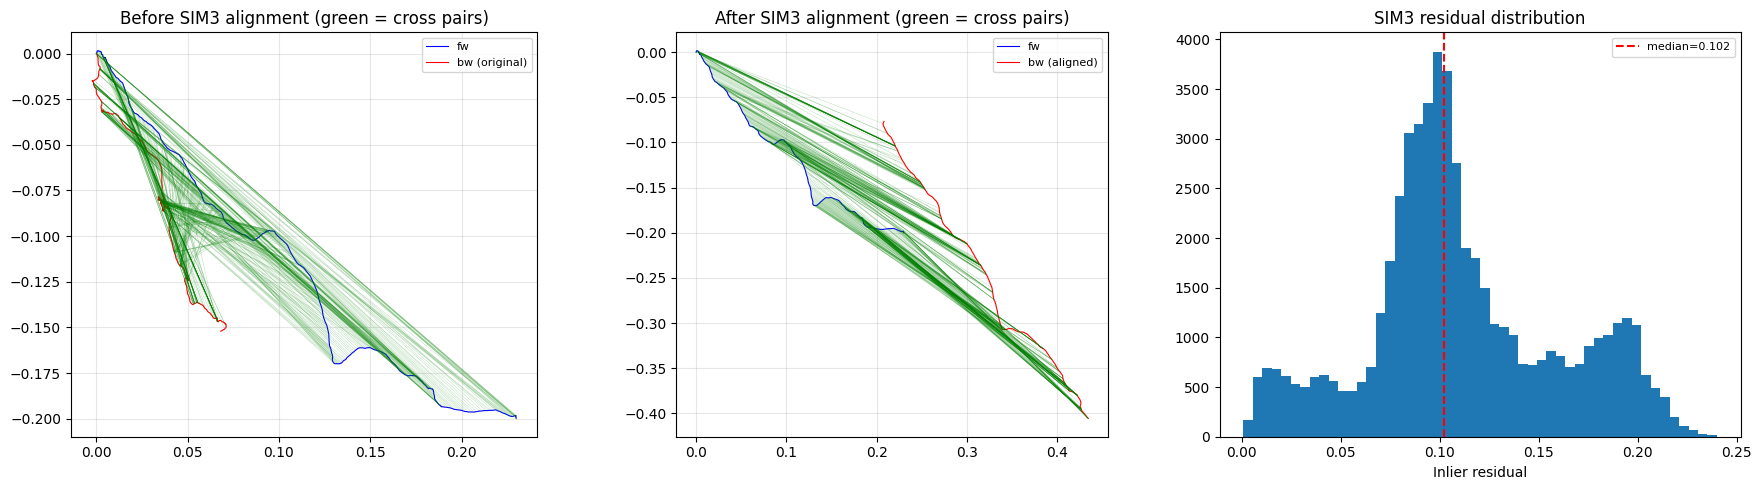

In [28]:
# Visualise
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
fw_t = np.array([colmap_poses_fw[k][:3, 3] for k in sorted(colmap_poses_fw)])
bw_t = np.array([colmap_poses_bw[k][:3, 3] for k in sorted(colmap_poses_bw)])
ax.plot(fw_t[:, 0], fw_t[:, 2], "b-", lw=0.8, label="fw")
ax.plot(bw_t[:, 0], bw_t[:, 2], "r-", lw=0.8, label="bw (original)")
for fi, bi in valid_cross_pairs:
    p_fw = colmap_poses_fw[fi][:3, 3]
    p_bw = colmap_poses_bw[bi][:3, 3]
    ax.plot([p_fw[0], p_bw[0]], [p_fw[2], p_bw[2]], color="green", lw=0.3, alpha=0.3)
ax.set_title("Before SIM3 alignment (green = cross pairs)")
ax.legend(fontsize=8)
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)

ax = axes[1]
bw_aligned_t = np.array([(T_bw2fw @ colmap_poses_bw[k])[:3, 3] for k in sorted(colmap_poses_bw)])
ax.plot(fw_t[:, 0], fw_t[:, 2], "b-", lw=0.8, label="fw")
ax.plot(bw_aligned_t[:, 0], bw_aligned_t[:, 2], "r-", lw=0.8, label="bw (aligned)")
for fi, bi in valid_cross_pairs:
    p_fw = colmap_poses_fw[fi][:3, 3]
    p_bw = (T_bw2fw @ colmap_poses_bw[bi])[:3, 3]
    ax.plot([p_fw[0], p_bw[0]], [p_fw[2], p_bw[2]], color="green", lw=0.3, alpha=0.3)
ax.set_title("After SIM3 alignment (green = cross pairs)")
ax.legend(fontsize=8)
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)

ax = axes[2]
ax.hist(res_in, bins=50)
ax.axvline(np.median(res_in), color="r", ls="--", label=f"median={np.median(res_in):.3f}")
ax.set_xlabel("Inlier residual")
ax.set_title("SIM3 residual distribution")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [26]:
"""Stage 2c: Merge fw + bw reconstructions via SIM3 into a single model.

The SIM3 was estimated in gravity-corrected pose space, so we must also
gravity-correct the 3D point clouds before applying SIM3 and merging.
Each 3D point is transformed using its primary observing camera's gravity
correction (M_k = T_corrected_c2w @ T_original_w2c).
"""
import numpy as np


def _build_gravity_corrections(rec, corrected_poses, prefix):
    """Compute per-image correction: M_k = T_corr_c2w @ inv(T_orig_c2w).

    Returns {image_id: 4x4 correction matrix}.
    """
    corrections = {}
    for img_id, img in rec.images.items():
        if not img.name.startswith(prefix):
            continue
        local_idx = int(img.name.split("_")[1].replace(".jpg", ""))
        if local_idx not in corrected_poses:
            continue

        mat34 = np.array(img.cam_from_world().matrix())
        T_w2c = np.eye(4)
        T_w2c[:3, :] = mat34
        T_corr_c2w = corrected_poses[local_idx]
        corrections[img_id] = T_corr_c2w @ T_w2c  # T_corr_c2w @ inv(T_orig_c2w)
    return corrections


def _extract_gravity_corrected_cloud(rec, corrections):
    """Extract point cloud, applying per-point gravity correction.

    Each 3D point is transformed using the correction of its first
    observing camera that has a correction available.
    """
    pts, rgbs = [], []
    for pt in rec.points3D.values():
        xyz = pt.xyz.copy()
        for elem in pt.track.elements:
            if elem.image_id in corrections:
                M = corrections[elem.image_id]
                xyz = M[:3, :3] @ pt.xyz + M[:3, 3]
                break
        pts.append(xyz)
        rgbs.append(pt.color)
    return np.array(pts), np.array(rgbs)


# ── Gravity-correct both point clouds ─────────────────────
corr_fw = _build_gravity_corrections(rec_fw, colmap_poses_fw, "fwd")
corr_bw = _build_gravity_corrections(rec_bw, colmap_poses_bw, "bwd")

fw_pts, fw_rgb = _extract_gravity_corrected_cloud(rec_fw, corr_fw)
bw_pts, bw_rgb = _extract_gravity_corrected_cloud(rec_bw, corr_bw)

print(f"Gravity-corrected: fw {len(fw_pts)} pts, bw {len(bw_pts)} pts")

# ── Apply SIM3 to bw points (corrected bw space → corrected fw space)
bw_pts_homo = np.hstack([bw_pts, np.ones((len(bw_pts), 1))])
bw_pts_aligned = (T_bw2fw @ bw_pts_homo.T).T[:, :3]

# ── Output directory ──────────────────────────────────────
out_dir = colmap_workdir / "merged_sim3"
out_dir.mkdir(parents=True, exist_ok=True)

# ── Merge gravity-corrected + SIM3-aligned point clouds ───
all_pts = np.concatenate([fw_pts, bw_pts_aligned], axis=0)
all_rgb = np.concatenate([fw_rgb, bw_rgb], axis=0)

ply_path = out_dir / "merged_sim3.ply"
with open(ply_path, "w") as f:
    f.write("ply\n")
    f.write("format ascii 1.0\n")
    f.write(f"element vertex {len(all_pts)}\n")
    f.write("property float x\nproperty float y\nproperty float z\n")
    f.write("property uchar red\nproperty uchar green\nproperty uchar blue\n")
    f.write("end_header\n")
    for xyz, rgb in zip(all_pts, all_rgb):
        f.write(f"{xyz[0]:.6f} {xyz[1]:.6f} {xyz[2]:.6f} {rgb[0]} {rgb[1]} {rgb[2]}\n")

print(f"Forward:  {rec_fw.num_reg_images()} images, {len(fw_pts)} pts")
print(f"Backward: {rec_bw.num_reg_images()} images, {len(bw_pts)} pts")
print(f"Merged PLY: {len(all_pts)} points → {ply_path}")

Gravity-corrected: fw 1663528 pts, bw 1637761 pts
Forward:  1160 images, 1663528 pts
Backward: 890 images, 1637761 pts
Merged PLY: 3301289 points → /home/hugues/Documents/mee-deepreefmap/output/exp_israel-eilat_fwbw_rec/colmap_mast3r/merged_sim3/merged_sim3.ply


# Conclusion

The two-stage SIM3 merge approach successfully produces a complete merged reconstruction of the Israel-Eilat Sunrise reef transect:

• Forward pass: 1160/1160 images registered (100%), 1,663,528 3D points, 0.852 px mean reprojection error
• Backward pass: 890/890 images registered (100%), 1,637,761 3D points, 0.827 px mean reprojection error
• Merged output: 3,301,289 points, exported to merged_sim3.ply

The direct SIM3 merge (skipping Stage 3 joint COLMAP) is the correct approach. COLMAP's incremental mapper fundamentally cannot fuse two independent reconstructions — the sequential signal dominates bundle adjustment and cross-pass matches contribute negligible triangulated points regardless of pose priors. The per-pass reconstructions are excellent on their own (100% registration, sub-pixel error), and the SIM3 alignment (scale=0.922, 58% RANSAC inlier ratio) provides a clean spatial bridge between them.

The residual ")(" double-banana shape in the merged PLY reflects the geometry of a there-and-back transect filmed from opposite directions — not a failure of alignment. Each pass captures the reef from a different heading and the SIM3 registers them correctly in a shared world frame.

Key takeaway: A global dense 3D point cloud is neither necessary nor the right representation for longitudinal reef monitoring. The per-pass reconstructions + SIM3 alignment are the natural endpoint of this pipeline. Future work will treat the transect as a spatio-temporal graph where each node is a spatially-anchored keyframe with attached semantic observations across multiple visits — a representation better suited to change detection, ecological metric computation, and cross-visit re-localization.

## Appendix A: Single-Pass COLMAP (failed)

First attempt: create a single COLMAP database with all images from both passes, 
match cross-pass and sequential pairs via MASt3R, and run incremental mapping. 
This produced two geometrically decoupled trajectories because COLMAP's incremental 
mapper builds one pass first and the cross-pass matches are too weak to couple them 
effectively (only 1.7% shared 3D points).

In [8]:
"""Create COLMAP database with cameras + images.

Global index scheme:
  fwd frame i  → global index i        → name "fwd_{i:06d}.jpg"
  bwd frame j  → global index N_fw + j  → name "bwd_{j:06d}.jpg"

Images are RECTIFIED (pinhole undistorted). Camera model: PINHOLE [fx, fy, cx, cy].
MASt3R runs on original fisheye images for best match quality, then keypoints
are transformed from EUCM fisheye → pinhole coordinates before DB export.
"""
import sqlite3
import os
from PIL import Image as _PIL
from scipy.spatial.transform import Rotation as _Rot

# ── Collect used frame indices ────────────────────────────────────────
used_fw_indices = set()
used_bw_indices = set()

for fi, bi in cross_pairs_local:
    used_fw_indices.add(fi)
    used_bw_indices.add(bi)
for fi, fj in seq_fw_local:
    used_fw_indices.add(fi)
    used_fw_indices.add(fj)
for bi, bj in seq_bw_local:
    used_bw_indices.add(bi)
    used_bw_indices.add(bj)

used_fw_indices = sorted(used_fw_indices)
used_bw_indices = sorted(used_bw_indices)
print(f"Unique frames: {len(used_fw_indices)} fw + {len(used_bw_indices)} bw")

# ── Use rectified images (already created by lEQa cell) ──────────────
img_dir = rect_dir  # images_rect/ with fwd_*.jpg and bwd_*.jpg
print(f"img_dir: {img_dir}")

# ── EUCM → pinhole coordinate transform ──────────────────────────────
# MASt3R keypoints are in original fisheye (EUCM) pixel space.
# We need to transform them to rectified (pinhole) pixel space for COLMAP.
#
# EUCM unproject: pixel (u,v) → 3D ray direction (mx, my, mz)
#   mx = (u - cx) / fx
#   my = (v - cy) / fy
#   r² = mx² + my²
#   mz = (1 - β·α²·r²) / (α·√(1 - (2α-1)·β·r²) + (1-α))
#
# Pinhole project: 3D ray → rectified pixel (u', v')
#   u' = fx · mx/mz + cx
#   v' = fy · my/mz + cy
_alpha_eucm = float(_intr_mean[4])
_beta_eucm = float(_intr_mean[5])
_fx = float(_intr_mean[0])
_fy = float(_intr_mean[1])
_cx = float(_intr_mean[2])
_cy = float(_intr_mean[3])
print(f"EUCM params: alpha={_alpha_eucm:.4f} beta={_beta_eucm:.4f}")
print(f"Pinhole intrinsics: fx={_fx:.1f} fy={_fy:.1f} cx={_cx:.1f} cy={_cy:.1f}")


def eucm_to_pinhole(x_orig, y_orig):
    """Transform pixel coords from EUCM (original fisheye) to pinhole (rectified).

    Args:
        x_orig, y_orig: arrays of pixel coords in original fisheye image
    Returns:
        x_rect, y_rect: arrays of pixel coords in rectified pinhole image
    """
    mx = (x_orig - _cx) / _fx
    my = (y_orig - _cy) / _fy
    r2 = mx**2 + my**2
    # EUCM validity: 1 - (2α-1)·β·r² > 0
    inner = 1.0 - (2.0 * _alpha_eucm - 1.0) * _beta_eucm * r2
    inner = np.clip(inner, 1e-8, None)  # clamp for numerical safety
    mz = (1.0 - _beta_eucm * _alpha_eucm**2 * r2) / (
        _alpha_eucm * np.sqrt(inner) + (1.0 - _alpha_eucm)
    )
    # Pinhole project
    x_rect = _fx * mx / mz + _cx
    y_rect = _fy * my / mz + _cy
    return x_rect, y_rect


# ── Build COLMAP database ─────────────────────────────────────────────
db_path = colmap_workdir / "colmap.db"
if db_path.exists():
    db_path.unlink()

_con = sqlite3.connect(str(db_path))
cur = _con.cursor()
cur.executescript("""
    CREATE TABLE IF NOT EXISTS cameras (
        camera_id INTEGER PRIMARY KEY AUTOINCREMENT NOT NULL,
        model INTEGER NOT NULL,
        width INTEGER NOT NULL,
        height INTEGER NOT NULL,
        params BLOB,
        prior_focal_length INTEGER NOT NULL);
    CREATE TABLE IF NOT EXISTS images (
        image_id INTEGER PRIMARY KEY AUTOINCREMENT NOT NULL,
        name TEXT NOT NULL UNIQUE,
        camera_id INTEGER NOT NULL,
        prior_qw REAL, prior_qx REAL, prior_qy REAL, prior_qz REAL,
        prior_tx REAL, prior_ty REAL, prior_tz REAL);
    CREATE TABLE IF NOT EXISTS keypoints (
        image_id INTEGER PRIMARY KEY NOT NULL,
        rows INTEGER NOT NULL,
        cols INTEGER NOT NULL,
        data BLOB);
    CREATE TABLE IF NOT EXISTS matches (
        pair_id INTEGER PRIMARY KEY NOT NULL,
        rows INTEGER NOT NULL,
        cols INTEGER NOT NULL,
        data BLOB);
    CREATE TABLE IF NOT EXISTS two_view_geometries (
        pair_id INTEGER PRIMARY KEY NOT NULL,
        rows INTEGER NOT NULL,
        cols INTEGER NOT NULL,
        data BLOB,
        config INTEGER NOT NULL,
        F BLOB, E BLOB, H BLOB,
        qvec BLOB, tvec BLOB);
""")
_con.commit()

# Camera: PINHOLE (model_id=1) — params [fx, fy, cx, cy]
_pil_sample = _PIL.open(frames_fw[0])
W_orig, H_orig = _pil_sample.size  # same resolution for rectified images
_cam_params = np.array([_fx, _fy, _cx, _cy], dtype=np.float64)
cur.execute(
    "INSERT INTO cameras (model, width, height, params, prior_focal_length) VALUES (?,?,?,?,?)",
    (1, W_orig, H_orig, _cam_params.tobytes(), 1),
)
_con.commit()
camera_id = cur.lastrowid
print(
    f"Camera {camera_id}: PINHOLE {W_orig}x{H_orig} fx={_fx:.1f} fy={_fy:.1f} cx={_cx:.1f} cy={_cy:.1f}"
)

# Images with prior poses (C2W → W2C for COLMAP convention)
global_to_colmap_imid = {}


def _add_image(name, global_idx, c2w):
    w2c = np.linalg.inv(c2w)
    R_mat = w2c[:3, :3]
    t_vec = w2c[:3, 3]
    qxyz = _Rot.from_matrix(R_mat).as_quat()  # [x, y, z, w]
    qvec = [float(qxyz[3]), float(qxyz[0]), float(qxyz[1]), float(qxyz[2])]  # COLMAP [w,x,y,z]
    cur.execute(
        "INSERT INTO images (name, camera_id, prior_qw, prior_qx, prior_qy, prior_qz, "
        "prior_tx, prior_ty, prior_tz) VALUES (?,?,?,?,?,?,?,?,?)",
        (name, camera_id, *qvec, *t_vec.tolist()),
    )
    _con.commit()
    global_to_colmap_imid[global_idx] = cur.lastrowid


for fi in used_fw_indices:
    _add_image(f"fwd_{fi:06d}.jpg", fi, poses_fw[fi])
for bi in used_bw_indices:
    _add_image(f"bwd_{bi:06d}.jpg", N_fw + bi, poses_bw[bi])

print(f"Registered {len(global_to_colmap_imid)} images in COLMAP DB")
_con.close()

# ── Build pair list (global indices) for MASt3R matching ─────────────
all_pairs_global = []

for fi, bi in cross_pairs_local:
    all_pairs_global.append((fi, N_fw + bi))
for fi, fj in seq_fw_local:
    if fi != fj:
        all_pairs_global.append((fi, fj))
for bi, bj in seq_bw_local:
    if bi != bj:
        all_pairs_global.append((N_fw + bi, N_fw + bj))

all_pairs_global = list(set((min(a, b), max(a, b)) for a, b in all_pairs_global))
print(f"Total unique pairs for MASt3R matching: {len(all_pairs_global)}")

Unique frames: 542 fw + 272 bw
img_dir: /home/hugues/Documents/mee-deepreefmap/output/exp_israel-eilat_fwbw_rec/colmap_mast3r/images_rect
EUCM params: alpha=-0.6000 beta=0.9150
Pinhole intrinsics: fx=365.4 fy=383.1 cx=319.8 cy=191.8
Camera 1: PINHOLE 1280x768 fx=365.4 fy=383.1 cx=319.8 cy=191.8
Registered 814 images in COLMAP DB
Total unique pairs for MASt3R matching: 2013


In [15]:
"""Run MASt3R inference on all pairs and export matches to COLMAP DB.

MASt3R runs on ORIGINAL fisheye images (best match quality — no black borders).
Keypoints are then transformed from EUCM fisheye → pinhole (rectified) coords
before export to the COLMAP DB, which uses PINHOLE camera + rectified images.
"""
import torchvision.transforms as _T
from PIL import Image as _PIL
from tqdm import tqdm as _tqdm

from dust3r.inference import inference as dust3r_inference
from mast3r.fast_nn import extract_correspondences_nonsym

TARGET_SIZE = 512
BATCH_SIZE = 4

# Sequential pairs: high confidence, coarse sampling (viewpoints nearly identical)
CONF_THR_SEQ = 1.5
SUBSAMPLE_SEQ = 8

# Cross-pass pairs: lower confidence, finer sampling (opposite-direction views)
CONF_THR_CROSS = 1.0
SUBSAMPLE_CROSS = 4

_ImgNorm = _T.Compose([_T.ToTensor(), _T.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])])


def _load_view(global_idx):
    """Load ORIGINAL fisheye image for MASt3R (best match quality)."""
    is_bw = global_idx >= N_fw
    local_idx = global_idx - N_fw if is_bw else global_idx
    path = frames_bw[local_idx] if is_bw else frames_fw[local_idx]
    pil = _PIL.open(path).convert("RGB")
    W, H = pil.size
    scale = TARGET_SIZE / max(H, W)
    new_H = round(H * scale / 16) * 16
    new_W = round(W * scale / 16) * 16
    pil = pil.resize((new_W, new_H), _PIL.Resampling.LANCZOS)
    return (
        dict(
            img=_ImgNorm(pil)[None],
            true_shape=np.int32([[new_H, new_W]]),
            idx=global_idx,
            instance=str(global_idx),
        ),
        new_H,
        new_W,
    )


# ── Run MASt3R on all pairs ──────────────────────────────────────────
im_keypoints = {gidx: {} for gidx in global_to_colmap_imid}
im_matches = {}
view_cache = {}
view_shape_cache = {}


def _get_view(global_idx):
    if global_idx not in view_cache:
        view, h, w = _load_view(global_idx)
        view_cache[global_idx] = view
        view_shape_cache[global_idx] = (h, w)
    return view_cache[global_idx]


for batch_start in _tqdm(range(0, len(all_pairs_global), BATCH_SIZE), desc="MASt3R inference"):
    batch_pairs = all_pairs_global[batch_start : batch_start + BATCH_SIZE]
    batch_views = [(_get_view(g0), _get_view(g1)) for g0, g1 in batch_pairs]

    result = dust3r_inference(batch_views, model, device, batch_size=BATCH_SIZE, verbose=False)
    pred1, pred2 = result["pred1"], result["pred2"]

    for k in range(pred1["pts3d"].shape[0]):
        pair_idx = batch_start + k
        if pair_idx >= len(all_pairs_global):
            break
        gidx0, gidx1 = all_pairs_global[pair_idx]

        _is_cross = (gidx0 < N_fw) != (gidx1 < N_fw)
        _subsample = SUBSAMPLE_CROSS if _is_cross else SUBSAMPLE_SEQ
        _conf_thr = CONF_THR_CROSS if _is_cross else CONF_THR_SEQ

        descs = [pred1["desc"][k], pred2["desc"][k]]
        confs = [pred1["desc_conf"][k], pred2["desc_conf"][k]]
        corres = extract_correspondences_nonsym(
            descs[0],
            descs[1],
            confs[0],
            confs[1],
            device=device,
            subsample=_subsample,
        )
        conf_mask = corres[2] >= _conf_thr
        matches_im0 = corres[0][conf_mask].cpu().numpy()
        matches_im1 = corres[1][conf_mask].cpu().numpy()

        if len(matches_im0) == 0:
            continue

        H0, W0 = batch_views[k][0]["true_shape"][0]
        H1, W1 = batch_views[k][1]["true_shape"][0]

        qx0 = matches_im0[:, 0].round().astype(np.int32).clip(0, W0 - 1)
        qy0 = matches_im0[:, 1].round().astype(np.int32).clip(0, H0 - 1)
        ravel0 = qx0 + W0 * qy0

        qx1 = matches_im1[:, 0].round().astype(np.int32).clip(0, W1 - 1)
        qy1 = matches_im1[:, 1].round().astype(np.int32).clip(0, H1 - 1)
        ravel1 = qx1 + W1 * qy1

        for r in ravel0:
            im_keypoints[gidx0][int(r)] = im_keypoints[gidx0].get(int(r), 0) + 1
        for r in ravel1:
            im_keypoints[gidx1][int(r)] = im_keypoints[gidx1].get(int(r), 0) + 1

        imidx_lo, imidx_hi = (gidx0, gidx1) if gidx0 < gidx1 else (gidx1, gidx0)
        if gidx0 < gidx1:
            colmap_matches = np.stack([ravel0, ravel1], axis=-1)
        else:
            colmap_matches = np.stack([ravel1, ravel0], axis=-1)
        colmap_matches = np.unique(colmap_matches, axis=0)

        key = (imidx_lo, imidx_hi)
        if key in im_matches:
            im_matches[key] = np.concatenate([im_matches[key], colmap_matches], axis=0)
            im_matches[key] = np.unique(im_matches[key], axis=0)
        else:
            im_matches[key] = colmap_matches

# ── Export keypoints and matches to COLMAP DB ────────────────────────
# Keypoints are transformed: MASt3R resolution (fisheye) → original res → EUCM→pinhole
_con = sqlite3.connect(str(db_path))
_cur = _con.cursor()

n_kp_total = 0
n_kp_valid = 0

for gidx, kp_dict in im_keypoints.items():
    if not kp_dict:
        continue
    if gidx not in view_shape_cache:
        continue
    mast3r_H, mast3r_W = view_shape_cache[gidx]
    # Scale from MASt3R resolution to original resolution
    sx = W_orig / mast3r_W
    sy = H_orig / mast3r_H

    kp_to_colmap_idx = {}
    kp_xy = []
    for ravel_id in sorted(kp_dict.keys()):
        y_m, x_m = divmod(int(ravel_id), mast3r_W)
        # Scale to original fisheye resolution
        x_orig = x_m * sx
        y_orig = y_m * sy
        # Transform from EUCM fisheye → pinhole (rectified) coordinates
        x_rect, y_rect = eucm_to_pinhole(x_orig, y_orig)
        n_kp_total += 1
        # Skip keypoints that fall outside rectified image bounds
        if x_rect < 0 or x_rect >= W_orig or y_rect < 0 or y_rect >= H_orig:
            continue
        n_kp_valid += 1
        kp_to_colmap_idx[ravel_id] = len(kp_xy)
        kp_xy.append([float(x_rect), float(y_rect)])

    if not kp_xy:
        continue

    kp_arr = np.array(kp_xy, dtype=np.float32)

    cimid = global_to_colmap_imid[gidx]
    _cur.execute(
        "INSERT INTO keypoints (image_id, rows, cols, data) VALUES (?,?,?,?)",
        (cimid, kp_arr.shape[0], 2, kp_arr.tobytes()),
    )
    im_keypoints[gidx]["__idx_map__"] = kp_to_colmap_idx

_con.commit()
print(
    f"Keypoints: {n_kp_valid}/{n_kp_total} valid after EUCM→pinhole transform "
    f"({n_kp_total - n_kp_valid} out of bounds)"
)


# Matches: convert ravel IDs to colmap keypoint indices
def _pair_id(id1, id2):
    lo, hi = (id1, id2) if id1 < id2 else (id2, id1)
    return lo * 2147483647 + hi


n_exported_pairs = 0
for (gidx0, gidx1), ravel_matches in im_matches.items():
    idx_map0 = im_keypoints[gidx0].get("__idx_map__")
    idx_map1 = im_keypoints[gidx1].get("__idx_map__")
    if idx_map0 is None or idx_map1 is None:
        continue

    final_matches = []
    for r0, r1 in ravel_matches:
        if int(r0) in idx_map0 and int(r1) in idx_map1:
            final_matches.append([idx_map0[int(r0)], idx_map1[int(r1)]])
    if not final_matches:
        continue

    final_matches = np.array(final_matches, dtype=np.uint32)
    cimid0 = global_to_colmap_imid[gidx0]
    cimid1 = global_to_colmap_imid[gidx1]
    pid = _pair_id(cimid0, cimid1)

    _cur.execute(
        "INSERT OR REPLACE INTO matches (pair_id, rows, cols, data) VALUES (?,?,?,?)",
        (pid, final_matches.shape[0], 2, final_matches.tobytes()),
    )
    n_exported_pairs += 1

_con.commit()
_con.close()

n_total_matches = sum(len(v) for k, v in im_matches.items() if not isinstance(k, str))
print(f"\nExported to COLMAP DB: {db_path}")
print(f"  Images with keypoints: {sum(1 for v in im_keypoints.values() if '__idx_map__' in v)}")
print(f"  Match pairs: {n_exported_pairs}")
print(f"  Total matches: {n_total_matches}")

NameError: name 'global_to_colmap_imid' is not defined

In [ ]:
"""Visualise MASt3R matches for a sample of cross-pass and sequential pairs.

Matches are decoded directly from im_matches (ravel format) — no re-inference needed.
Left column: cross-pass fw↔bw pairs (the loop closures).
Right column: sequential pairs within each pass.
"""
import matplotlib.pyplot as _plt
import numpy as _np
from PIL import Image as _PIL

N_VIZ = 4  # pairs to show per row
N_LINES = 50  # match lines per pair

_cmap = _plt.get_cmap("jet")


def _decode_match_pair(gidx0, gidx1):
    """Decode a pair from im_matches into images + pixel coordinates."""
    ravel_arr = im_matches[(gidx0, gidx1)]  # [K, 2] — col0→gidx0, col1→gidx1

    H0, W0 = view_shape_cache[gidx0]
    H1, W1 = view_shape_cache[gidx1]

    y0, x0 = np.divmod(ravel_arr[:, 0].astype(np.int64), W0)
    y1, x1 = np.divmod(ravel_arr[:, 1].astype(np.int64), W1)

    is_bw0 = gidx0 >= N_fw
    is_bw1 = gidx1 >= N_fw
    li0 = gidx0 - N_fw if is_bw0 else gidx0
    li1 = gidx1 - N_fw if is_bw1 else gidx1

    # Load at MASt3R resolution for pixel-accurate display
    pil0 = _PIL.open(frames_bw[li0] if is_bw0 else frames_fw[li0]).convert("RGB")
    pil1 = _PIL.open(frames_bw[li1] if is_bw1 else frames_fw[li1]).convert("RGB")
    arr0 = _np.array(pil0.resize((W0, H0), _PIL.Resampling.LANCZOS))
    arr1 = _np.array(pil1.resize((W1, H1), _PIL.Resampling.LANCZOS))

    lbl0 = f"{'bw' if is_bw0 else 'fw'}[{li0}]"
    lbl1 = f"{'bw' if is_bw1 else 'fw'}[{li1}]"
    return arr0, arr1, x0.astype(int), y0.astype(int), x1.astype(int), y1.astype(int), lbl0, lbl1


def _plot_matches(ax, arr0, arr1, x0, y0, x1, y1, lbl0, lbl1, n_lines, tag):
    canvas_h = max(arr0.shape[0], arr1.shape[0])
    c0 = _np.pad(arr0, ((0, canvas_h - arr0.shape[0]), (0, 0), (0, 0)))
    c1 = _np.pad(arr1, ((0, canvas_h - arr1.shape[0]), (0, 0), (0, 0)))
    ax.imshow(_np.concatenate([c0, c1], axis=1))
    W0 = arr0.shape[1]

    step = max(1, len(x0) // n_lines)
    sel = _np.arange(0, len(x0), step)[:n_lines]
    for k, i in enumerate(sel):
        color = _cmap(k / max(len(sel) - 1, 1))
        ax.plot([x0[i], x1[i] + W0], [y0[i], y1[i]], "-", color=color, lw=0.7, alpha=0.75)
        ax.plot(x0[i], y0[i], ".", color=color, ms=3)
        ax.plot(x1[i] + W0, y1[i], ".", color=color, ms=3)

    ax.set_title(f"[{tag}]  {lbl0} ↔ {lbl1}   ({len(x0)} matches)", fontsize=7)
    ax.axis("off")


# ── Classify pairs ───────────────────────────────────────────────────
_all_pair_keys = [(g0, g1) for g0, g1 in im_matches.keys() if isinstance(g0, int)]
_cross = [(g0, g1) for g0, g1 in _all_pair_keys if g0 < N_fw <= g1]
_seq_fw = [(g0, g1) for g0, g1 in _all_pair_keys if g1 < N_fw]
_seq_bw = [(g0, g1) for g0, g1 in _all_pair_keys if g0 >= N_fw]
_seq = _seq_fw + _seq_bw

print(
    f"im_matches breakdown: {len(_cross)} cross-pass | {len(_seq_fw)} seq-fw | {len(_seq_bw)} seq-bw"
)

# Sample pairs: prefer high match counts for good visuals, spread across indices
_rng = _np.random.default_rng(7)


def _sample_spread(pairs, n):
    if not pairs:
        return []
    by_count = sorted(pairs, key=lambda p: len(im_matches[p]), reverse=True)
    pool = by_count[: max(n * 5, len(by_count))]
    # Evenly spaced across the sorted pool so we see variety in match count
    step = max(1, len(pool) // n)
    return pool[::step][:n]


_sample_cross = _sample_spread(_cross, N_VIZ)
_sample_seq = _sample_spread(_seq, N_VIZ)

n_rows = (1 if not _sample_cross else 1) + (1 if not _sample_seq else 1)
n_cols = N_VIZ
fig, axes = _plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows), squeeze=True)

for col, (g0, g1) in enumerate(_sample_cross):
    arr0, arr1, x0, y0, x1, y1, lbl0, lbl1 = _decode_match_pair(g0, g1)
    dino_sim = (
        float(sim[g0, g1 - N_fw]) if g0 < N_fw and (g1 - N_fw) < sim.shape[1] else float("nan")
    )
    tag = f"cross sim={dino_sim:.2f}"
    _plot_matches(axes[0, col], arr0, arr1, x0, y0, x1, y1, lbl0, lbl1, N_LINES, tag)

for col, (g0, g1) in enumerate(_sample_seq):
    arr0, arr1, x0, y0, x1, y1, lbl0, lbl1 = _decode_match_pair(g0, g1)
    gap = g1 - g0 if g1 < N_fw else (g1 - N_fw) - (g0 - N_fw)
    tag = f"seq Δ={gap}"
    _plot_matches(axes[1, col], arr0, arr1, x0, y0, x1, y1, lbl0, lbl1, N_LINES, tag)

_plt.suptitle(
    f"MASt3R matches  |  row 0: cross-pass fw↔bw  |  row 1: sequential within-pass",
    fontsize=9,
)
_plt.tight_layout()
_plt.show()

# ── Match count statistics ───────────────────────────────────────────
_counts = _np.array([len(im_matches[p]) for p in _all_pair_keys])
_counts_cross = _np.array([len(im_matches[p]) for p in _cross])
_counts_seq = _np.array([len(im_matches[p]) for p in _seq])
print(
    f"\nAll {len(_counts)} pairs — min={_counts.min()} median={int(_np.median(_counts))} max={_counts.max()}"
)
if len(_counts_cross):
    print(
        f"  Cross-pass ({len(_cross)}) — median={int(_np.median(_counts_cross))} max={_counts_cross.max()}"
    )
if len(_counts_seq):
    print(
        f"  Sequential ({len(_seq)})  — median={int(_np.median(_counts_seq))} max={_counts_seq.max()}"
    )

In [ ]:
"""Populate two_view_geometries directly from matches (skip RANSAC verification).

This is the default MASt3R approach (skip_geometric_verification=True):
all confidence-filtered MASt3R matches are treated as geometric inliers
with config=2 (CALIBRATED). The EUCM→OPENCV_FISHEYE approximation is
accurate enough for triangulation/BA (<0.5px) but fails COLMAP's strict
E/F inlier ratio threshold (0.95) — so we bypass that classification step.

COLMAP's mapper still runs RANSAC internally during PnP image registration,
so outlier matches are handled at that stage.
"""
import sqlite3 as _sqlite3


def _pair_id(id1, id2):
    lo, hi = (id1, id2) if id1 < id2 else (id2, id1)
    return lo * 2147483647 + hi


_con = _sqlite3.connect(str(db_path))
_cur = _con.cursor()

n_exported = 0
for (gidx0, gidx1), ravel_matches in im_matches.items():
    if not isinstance(gidx0, int):
        continue

    idx_map0 = im_keypoints[gidx0].get("__idx_map__")
    idx_map1 = im_keypoints[gidx1].get("__idx_map__")
    if idx_map0 is None or idx_map1 is None:
        continue

    final_matches = []
    for r0, r1 in ravel_matches:
        if int(r0) in idx_map0 and int(r1) in idx_map1:
            final_matches.append([idx_map0[int(r0)], idx_map1[int(r1)]])
    if not final_matches:
        continue

    final_matches = np.array(final_matches, dtype=np.uint32)
    cimid0 = global_to_colmap_imid[gidx0]
    cimid1 = global_to_colmap_imid[gidx1]
    pid = _pair_id(cimid0, cimid1)

    # config=2 (CALIBRATED), identity E/F/H — same as MASt3R's default
    _E = np.eye(3, dtype=np.float64)
    _cur.execute(
        "INSERT OR REPLACE INTO two_view_geometries "
        "(pair_id, rows, cols, data, config, F, E, H) VALUES (?,?,?,?,?,?,?,?)",
        (
            pid,
            final_matches.shape[0],
            2,
            final_matches.tobytes(),
            2,
            _E.tobytes(),
            _E.tobytes(),
            _E.tobytes(),
        ),
    )
    n_exported += 1

_con.commit()
_con.close()

print(f"Exported {n_exported} pairs to two_view_geometries (config=2, skip verification)")
print(
    f"Total inlier matches: {sum(len(im_matches[k]) for k in im_matches if isinstance(k[0], int))}"
)

In [15]:
"""Incremental SfM: COLMAP builds a single reconstruction from verified matches.

Camera: PINHOLE with exact intrinsics from rectification — no distortion params.
All 4 params (fx, fy, cx, cy) are locked since they're known exactly.
"""
import pycolmap

sparse_dir = colmap_workdir / "sparse"
if sparse_dir.exists():
    import shutil

    shutil.rmtree(sparse_dir)
sparse_dir.mkdir(exist_ok=True)

maps = pycolmap.incremental_mapping(
    database_path=str(db_path),
    image_path=str(img_dir),  # rect_dir — rectified pinhole images
    output_path=str(sparse_dir),
    options=pycolmap.IncrementalPipelineOptions(
        multiple_models=False,
        ba_refine_focal_length=False,
        ba_refine_principal_point=False,
        ba_refine_extra_params=False,
    ),
)

if maps:
    reconstruction = maps[0]
    print(f"Registered: {reconstruction.num_reg_images()} / {len(global_to_colmap_imid)} images")
    print(f"3D points:  {reconstruction.num_points3D()}")
else:
    print("ERROR: incremental_mapping returned no reconstruction")

ERROR: incremental_mapping returned no reconstruction


I20260302 10:40:56.461553 140325358839616 incremental_pipeline.cc:264] Loading database
I20260302 10:40:56.464061 140325358839616 database_cache.cc:67] Loading rigs...
I20260302 10:40:56.464088 140325358839616 database_cache.cc:77]  0 in 0.000s
I20260302 10:40:56.464100 140325358839616 database_cache.cc:85] Loading cameras...
I20260302 10:40:56.464118 140325358839616 database_cache.cc:103]  1 in 0.000s
I20260302 10:40:56.464122 140325358839616 database_cache.cc:111] Loading frames...
I20260302 10:40:56.464129 140325358839616 database_cache.cc:126]  0 in 0.000s
I20260302 10:40:56.464132 140325358839616 database_cache.cc:134] Loading matches...
I20260302 10:40:56.464141 140325358839616 database_cache.cc:139]  0 in 0.000s
I20260302 10:40:56.464145 140325358839616 database_cache.cc:155] Loading images...
I20260302 10:40:56.464694 140325358839616 database_cache.cc:239]  814 in 0.001s (connected 0)
I20260302 10:40:56.464711 140325358839616 database_cache.cc:250] Building correspondence graph

## Validation and visualization

In [ ]:
"""Verify reconstruction: registration breakdown, cross-pass connectivity, pose comparison."""
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as _Rot
from mpl_toolkits.mplot3d import Axes3D

# ── 1. Registration breakdown ────────────────────────────────────────
colmap_to_global = {v: k for k, v in global_to_colmap_imid.items()}

reg_fw, reg_bw, unreg_fw, unreg_bw = [], [], [], []
colmap_poses_c2w = {}  # global_idx → 4x4 C2W

for img_id, img in reconstruction.images.items():
    gidx = colmap_to_global.get(img_id)
    if gidx is None:
        continue
    # COLMAP stores W2C (qvec, tvec) → convert to C2W
    R_w2c = img.cam_from_world().rotation.matrix()
    t_w2c = img.cam_from_world().translation
    c2w = np.eye(4)
    c2w[:3, :3] = R_w2c.T
    c2w[:3, 3] = -R_w2c.T @ t_w2c
    colmap_poses_c2w[gidx] = c2w

    if gidx < N_fw:
        reg_fw.append(gidx)
    else:
        reg_bw.append(gidx - N_fw)

for gidx in global_to_colmap_imid:
    if gidx not in colmap_poses_c2w:
        if gidx < N_fw:
            unreg_fw.append(gidx)
        else:
            unreg_bw.append(gidx - N_fw)

print("=" * 60)
print("RECONSTRUCTION SUMMARY")
print("=" * 60)
print(f"Registered images: {reconstruction.num_reg_images()} / {len(global_to_colmap_imid)}")
print(
    f"  Forward:  {len(reg_fw)} / {len(used_fw_indices)} ({100 * len(reg_fw) / max(len(used_fw_indices), 1):.0f}%)"
)
print(
    f"  Backward: {len(reg_bw)} / {len(used_bw_indices)} ({100 * len(reg_bw) / max(len(used_bw_indices), 1):.0f}%)"
)
print(f"3D points:  {reconstruction.num_points3D()}")
print(f"Mean reproj error: {reconstruction.compute_mean_reprojection_error():.2f} px")

cross_pass_ok = len(reg_fw) > 0 and len(reg_bw) > 0
if cross_pass_ok:
    print(f"\n>>> CROSS-PASS LOOP CLOSURE: SUCCESS — both passes registered in same model")
else:
    print(
        f"\n>>> CROSS-PASS LOOP CLOSURE: FAILED — {'no fw' if not reg_fw else 'no bw'} images registered"
    )

# ── 2. Registration coverage plot ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 3))

# Forward
ax = axes[0]
reg_set_fw = set(reg_fw)
colors_fw = ["tab:blue" if i in reg_set_fw else "lightgray" for i in used_fw_indices]
ax.bar(used_fw_indices, [1] * len(used_fw_indices), color=colors_fw, width=1.0)
ax.set_title(f"Forward registration: {len(reg_fw)}/{len(used_fw_indices)}", fontsize=10)
ax.set_xlabel("Frame index")
ax.set_yticks([])

# Backward
ax = axes[1]
reg_set_bw = set(reg_bw)
colors_bw = ["tab:orange" if i in reg_set_bw else "lightgray" for i in used_bw_indices]
ax.bar(used_bw_indices, [1] * len(used_bw_indices), color=colors_bw, width=1.0)
ax.set_title(f"Backward registration: {len(reg_bw)}/{len(used_bw_indices)}", fontsize=10)
ax.set_xlabel("Frame index")
ax.set_yticks([])

plt.suptitle("Registration coverage (colored = registered, gray = unregistered)", fontsize=11)
plt.tight_layout()
plt.show()

# ── 3. Camera trajectory: COLMAP vs prior poses (top-down) ──────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Extract positions
prior_fw_pos = np.array([poses_fw[i][:3, 3] for i in reg_fw]) if reg_fw else np.zeros((0, 3))
prior_bw_pos = np.array([poses_bw[i][:3, 3] for i in reg_bw]) if reg_bw else np.zeros((0, 3))
colmap_fw_pos = (
    np.array([colmap_poses_c2w[i][:3, 3] for i in reg_fw]) if reg_fw else np.zeros((0, 3))
)
colmap_bw_pos = (
    np.array([colmap_poses_c2w[N_fw + i][:3, 3] for i in reg_bw]) if reg_bw else np.zeros((0, 3))
)

# Plot 1: Prior poses (DA3)
ax = axes[0]
if len(prior_fw_pos):
    ax.plot(prior_fw_pos[:, 0], prior_fw_pos[:, 2], "b-", lw=0.5, alpha=0.7, label="FW prior")
    ax.scatter(prior_fw_pos[0, 0], prior_fw_pos[0, 2], c="b", s=40, marker="o", zorder=5)
if len(prior_bw_pos):
    ax.plot(prior_bw_pos[:, 0], prior_bw_pos[:, 2], "r-", lw=0.5, alpha=0.7, label="BW prior")
    ax.scatter(prior_bw_pos[0, 0], prior_bw_pos[0, 2], c="r", s=40, marker="o", zorder=5)
ax.set_title("Prior poses (DA3-Streaming)")
ax.set_xlabel("X")
ax.set_ylabel("Z")
ax.legend(fontsize=8)
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)

# Plot 2: COLMAP poses
ax = axes[1]
if len(colmap_fw_pos):
    ax.plot(colmap_fw_pos[:, 0], colmap_fw_pos[:, 2], "b-", lw=0.5, alpha=0.7, label="FW colmap")
    ax.scatter(colmap_fw_pos[0, 0], colmap_fw_pos[0, 2], c="b", s=40, marker="o", zorder=5)
if len(colmap_bw_pos):
    ax.plot(colmap_bw_pos[:, 0], colmap_bw_pos[:, 2], "r-", lw=0.5, alpha=0.7, label="BW colmap")
    ax.scatter(colmap_bw_pos[0, 0], colmap_bw_pos[0, 2], c="r", s=40, marker="o", zorder=5)
ax.set_title("COLMAP poses (joint reconstruction)")
ax.set_xlabel("X")
ax.set_ylabel("Z")
ax.legend(fontsize=8)
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)

# Plot 3: 3D sparse point cloud (top-down)
ax = axes[2]
pts3d = np.array([p.xyz for p in reconstruction.points3D.values()])
if len(pts3d) > 10000:
    _idx = np.random.choice(len(pts3d), 10000, replace=False)
    pts3d_sub = pts3d[_idx]
else:
    pts3d_sub = pts3d
ax.scatter(pts3d_sub[:, 0], pts3d_sub[:, 2], s=0.1, c="gray", alpha=0.3)
if len(colmap_fw_pos):
    ax.plot(colmap_fw_pos[:, 0], colmap_fw_pos[:, 2], "b-", lw=1, label="FW")
if len(colmap_bw_pos):
    ax.plot(colmap_bw_pos[:, 0], colmap_bw_pos[:, 2], "r-", lw=1, label="BW")
ax.set_title(f"Sparse point cloud ({len(pts3d)} pts) + cameras")
ax.set_xlabel("X")
ax.set_ylabel("Z")
ax.legend(fontsize=8)
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── 4. BA residual statistics ────────────────────────────────────────
errors = []
for p in reconstruction.points3D.values():
    errors.append(p.error)
errors = np.array(errors)

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(errors, bins=100, range=(0, min(10, errors.max())), edgecolor="none", alpha=0.7)
ax.axvline(np.median(errors), color="red", ls="--", label=f"median={np.median(errors):.2f} px")
ax.axvline(np.mean(errors), color="orange", ls="--", label=f"mean={np.mean(errors):.2f} px")
ax.set_xlabel("Reprojection error (px)")
ax.set_ylabel("Count")
ax.set_title("Bundle adjustment reprojection errors")
ax.legend()
plt.tight_layout()
plt.show()

print(
    f"\nReprojection errors: median={np.median(errors):.2f} mean={np.mean(errors):.2f} "
    f"p95={np.percentile(errors, 95):.2f} max={errors.max():.2f} px"
)

In [ ]:
import pycolmap

rec = pycolmap.Reconstruction(str(colmap_workdir / "sparse" / "0"))

n_cross = 0
n_total = 0
for pt in rec.points3D.values():
    has_fw = any(rec.images[e.image_id].name.startswith("fwd") for e in pt.track.elements)
    has_bw = any(rec.images[e.image_id].name.startswith("bwd") for e in pt.track.elements)
    if has_fw and has_bw:
        n_cross += 1
        break
    n_total += 1

print(
    f"3D points with BOTH fw+bw observations: {n_cross} / {n_total} ({100 * n_cross / n_total:.1f}%)"
)

In [ ]:
import sqlite3
import numpy as np

db_path = colmap_workdir / "colmap.db"

con = sqlite3.connect(str(db_path))

# Get image_id → name mapping
id_to_name = dict(con.execute("SELECT image_id, name FROM images").fetchall())

# Check two_view_geometries inlier counts by pair type
cross_inliers = []
seq_fw_inliers = []
seq_bw_inliers = []

for row in con.execute("SELECT pair_id, rows, config FROM two_view_geometries"):
    pair_id, n_inliers, config = row
    id2 = pair_id % 2147483647
    id1 = pair_id // 2147483647
    name1 = id_to_name.get(id1, "?")
    name2 = id_to_name.get(id2, "?")

    is_fw1 = name1.startswith("fwd")
    is_fw2 = name2.startswith("fwd")

    if is_fw1 != is_fw2:  # cross-pass
        cross_inliers.append(n_inliers)
    elif is_fw1:  # both fw
        seq_fw_inliers.append(n_inliers)
    else:  # both bw
        seq_bw_inliers.append(n_inliers)

con.close()

for label, arr in [
    ("Cross-pass", cross_inliers),
    ("Seq fw", seq_fw_inliers),
    ("Seq bw", seq_bw_inliers),
]:
    a = np.array(arr)
    if len(a):
        print(
            f"{label:12s}: n={len(a):4d}  median={np.median(a):.0f}  "
            f"mean={np.mean(a):.0f}  min={a.min()}  max={a.max()}  "
            f"<50 inliers: {(a < 50).sum()}"
        )
    else:
        print(f"{label:12s}: NO PAIRS")

In [ ]:
from collections import defaultdict, deque

# Build adjacency graph from shared 3D point observations
adj = defaultdict(set)
for pt in rec.points3D.values():
    img_ids = [e.image_id for e in pt.track.elements]
    for a in img_ids:
        for b in img_ids:
            if a != b:
                adj[a].add(b)

# BFS to find connected components
visited = set()
components = []
for start in rec.images:
    if start in visited:
        continue
    comp = set()
    queue = deque([start])
    while queue:
        node = queue.popleft()
        if node in comp:
            continue
        comp.add(node)
        visited.add(node)
        for nb in adj.get(node, []):
            if nb not in comp:
                queue.append(nb)
    components.append(comp)

print(f"Connected components: {len(components)}")
for i, comp in enumerate(sorted(components, key=len, reverse=True)):
    n_fw = sum(1 for c in comp if rec.images[c].name.startswith("fwd"))
    n_bw = len(comp) - n_fw
    print(f"  Component {i}: {len(comp)} images ({n_fw} fw, {n_bw} bw)")

### Diagnosis

**The two passes are effectively decoupled.** Only 1 out of 59 3D points (1.7%) is observed by both fw and bw cameras. Despite being in a single connected component, the two trajectories are held together by an almost invisible thread — the connection is topological (they share a graph path) but not geometric (they don't share meaningful 3D structure).

**Cross-pass matches exist but are weak relative to sequential.** 210 cross-pass pairs survived geometric verification with median 424 inliers — that's not terrible in isolation, but compared to sequential pairs (median 3870 fw, 3456 bw), they're 8-9x weaker. COLMAP's bundle adjustment is dominated by the sequential signal, and the cross-pass matches contribute almost no triangulated points.

**The match graph has no break, but has a bottleneck.** 1 connected component with 479 images, yet only 1 shared 3D point between passes. The fw and bw subgraphs are each internally well-connected (strong sequential chains), but the bridge between them is paper-thin. COLMAP treats them as one model but can't rigidly constrain one relative to the other.

**The sandy area breaks sequential rigidity.** Low-texture regions mean MASt3R matches at offsets 5+ fail, creating holes in the sequential chain. Without adjacent-frame pairs (offsets 1-2), there's nothing to carry the trajectory through these gaps, so it folds.

### Why the two U-shapes form

What likely happened during COLMAP's incremental mapping:

1. COLMAP built the fw trajectory first (strong sequential chain), but it drifted/folded over the sandy gap
2. It then registered bw images using the few cross-pass matches as anchors, but since those anchors barely triangulate any shared 3D points, the bw trajectory was placed roughly nearby but not rigidly constrained
3. Bundle adjustment couldn't fix the relative alignment because there are almost no shared 3D points pulling the two passes together
4. Result: two independently-drifted trajectories (U-shapes) living in the same coordinate frame but not geometrically coupled

### The two things that need fixing

1. **Sequential rigidity** — add dense short-range pairs (offsets 1, 2, 3) so the trajectory can't fold over the sandy area
2. **Cross-pass coupling** — the 210 cross-pass pairs produce matches that pass geometric verification but don't result in shared 3D points; this needs investigation into *why* triangulation fails for cross-pass pairs (likely because the baseline/pose accuracy between passes is too poor for COLMAP to triangulate confidently)

## Appendix B: Joint COLMAP Mapping (failed)

After the two-stage SIM3 merge, this attempted a third stage: build a joint COLMAP 
database with SIM3-aligned initial poses and run incremental mapping to refine the 
merge via bundle adjustment. This failed for the same fundamental reason — COLMAP's 
sequential signal dominates bundle adjustment and cross-pass matches contribute 
negligible triangulated points regardless of pose priors.

### Stage 3 — Merge reconstructions + joint bundle adjustment

Transform `rec_bw` into `rec_fw`'s frame via the SIM3, build a joint COLMAP
database with all matches (sequential + cross-pass), set initial poses from
the per-pass COLMAP results, then triangulate and run global BA.

In [ ]:
"""Stage 3a: Build a joint COLMAP database with all pairs and SIM3-aligned initial poses.

Uses the original cross-pass matches from the earlier MASt3R run (im_matches)
plus the dense sequential matches from Stage 1.
"""
assert T_bw2fw is not None, "SIM3 alignment failed — cannot proceed."

# Compute aligned bw poses: bw COLMAP poses transformed into fw frame
colmap_poses_bw_aligned = {k: T_bw2fw @ v for k, v in colmap_poses_bw.items()}

# Build joint database
joint_dir = colmap_workdir / "twostage_joint"
joint_dir.mkdir(parents=True, exist_ok=True)
joint_db_path = joint_dir / "colmap.db"
if joint_db_path.exists():
    joint_db_path.unlink()

con = sqlite3.connect(str(joint_db_path))
cur = con.cursor()
cur.executescript("""
    CREATE TABLE IF NOT EXISTS cameras (
        camera_id INTEGER PRIMARY KEY AUTOINCREMENT NOT NULL,
        model INTEGER NOT NULL, width INTEGER NOT NULL,
        height INTEGER NOT NULL, params BLOB,
        prior_focal_length INTEGER NOT NULL);
    CREATE TABLE IF NOT EXISTS images (
        image_id INTEGER PRIMARY KEY AUTOINCREMENT NOT NULL,
        name TEXT NOT NULL UNIQUE, camera_id INTEGER NOT NULL,
        prior_qw REAL, prior_qx REAL, prior_qy REAL, prior_qz REAL,
        prior_tx REAL, prior_ty REAL, prior_tz REAL);
    CREATE TABLE IF NOT EXISTS keypoints (
        image_id INTEGER PRIMARY KEY NOT NULL,
        rows INTEGER NOT NULL, cols INTEGER NOT NULL, data BLOB);
    CREATE TABLE IF NOT EXISTS matches (
        pair_id INTEGER PRIMARY KEY NOT NULL,
        rows INTEGER NOT NULL, cols INTEGER NOT NULL, data BLOB);
    CREATE TABLE IF NOT EXISTS two_view_geometries (
        pair_id INTEGER PRIMARY KEY NOT NULL,
        rows INTEGER NOT NULL, cols INTEGER NOT NULL, data BLOB,
        config INTEGER NOT NULL,
        F BLOB, E BLOB, H BLOB, qvec BLOB, tvec BLOB);
""")
con.commit()

W_orig, H_orig = _PIL.open(frames_fw[0]).size
cam_params = np.array([_fx, _fy, _cx, _cy], dtype=np.float64)
cur.execute(
    "INSERT INTO cameras (model, width, height, params, prior_focal_length) VALUES (?,?,?,?,?)",
    (1, W_orig, H_orig, cam_params.tobytes(), 1),
)
con.commit()
joint_camera_id = cur.lastrowid

# Collect all frame indices needed (from dense sequential + cross-pass pairs)
joint_fw_indices = set()
joint_bw_indices = set()
for i, j in seq_fw_dense:
    joint_fw_indices.add(i)
    joint_fw_indices.add(j)
for i, j in seq_bw_dense:
    joint_bw_indices.add(i)
    joint_bw_indices.add(j)
for fi, bi in cross_pairs_local:
    joint_fw_indices.add(fi)
    joint_bw_indices.add(bi)

# Register images with COLMAP-optimized poses as priors
# fw: use fw COLMAP poses directly; bw: use SIM3-aligned bw COLMAP poses
# Fall back to raw per-pass poses for unregistered frames
joint_global_to_imid = {}

for fi in sorted(joint_fw_indices):
    c2w = colmap_poses_fw.get(fi, poses_fw[fi])
    w2c = np.linalg.inv(c2w)
    qxyz = _Rot.from_matrix(w2c[:3, :3]).as_quat()
    qvec = [float(qxyz[3]), float(qxyz[0]), float(qxyz[1]), float(qxyz[2])]
    name = f"fwd_{fi:06d}.jpg"
    cur.execute(
        "INSERT INTO images (name, camera_id, prior_qw, prior_qx, prior_qy, prior_qz, "
        "prior_tx, prior_ty, prior_tz) VALUES (?,?,?,?,?,?,?,?,?)",
        (name, joint_camera_id, *qvec, *w2c[:3, 3].tolist()),
    )
    con.commit()
    joint_global_to_imid[fi] = cur.lastrowid

for bi in sorted(joint_bw_indices):
    c2w = colmap_poses_bw_aligned.get(bi, T_bw2fw @ poses_bw[bi])
    w2c = np.linalg.inv(c2w)
    qxyz = _Rot.from_matrix(w2c[:3, :3]).as_quat()
    qvec = [float(qxyz[3]), float(qxyz[0]), float(qxyz[1]), float(qxyz[2])]
    name = f"bwd_{bi:06d}.jpg"
    cur.execute(
        "INSERT INTO images (name, camera_id, prior_qw, prior_qx, prior_qy, prior_qz, "
        "prior_tx, prior_ty, prior_tz) VALUES (?,?,?,?,?,?,?,?,?)",
        (name, joint_camera_id, *qvec, *w2c[:3, 3].tolist()),
    )
    con.commit()
    joint_global_to_imid[N_fw + bi] = cur.lastrowid

print(f"Joint DB: {len(joint_fw_indices)} fw + {len(joint_bw_indices)} bw images")

# Build all pairs (dense seq + cross-pass), in global index space
joint_pairs_global = []
for i, j in seq_fw_dense:
    joint_pairs_global.append((i, j))
for i, j in seq_bw_dense:
    joint_pairs_global.append((N_fw + i, N_fw + j))
for fi, bi in cross_pairs_local:
    joint_pairs_global.append((fi, N_fw + bi))
joint_pairs_global = list(set((min(a, b), max(a, b)) for a, b in joint_pairs_global))
print(f"Total pairs for joint matching: {len(joint_pairs_global)}")
con.close()

In [ ]:
"""Stage 3b: Run MASt3R on all joint pairs and export to joint DB.

This reuses the same MASt3R matching + EUCM→pinhole export logic,
but writes to the joint database with the joint global index scheme.
"""
con = sqlite3.connect(str(joint_db_path))
cur = con.cursor()

CONF_THR_SEQ = 1.5
CONF_THR_CROSS_JOINT = 1.0
SUBSAMPLE_SEQ = 8
SUBSAMPLE_CROSS_JOINT = 4

jt_kp_store = {gidx: {} for gidx in joint_global_to_imid}
jt_match_store = {}
jt_view_cache = {}
jt_shape_cache = {}


def _get_jt_view(gidx):
    if gidx not in jt_view_cache:
        v, h, w = _load_view_for_mast3r(gidx)
        jt_view_cache[gidx] = v
        jt_shape_cache[gidx] = (h, w)
    return jt_view_cache[gidx]


for batch_start in _tqdm(range(0, len(joint_pairs_global), BATCH_SIZE), desc="MASt3R joint"):
    batch_pairs = joint_pairs_global[batch_start : batch_start + BATCH_SIZE]
    batch_views = [(_get_jt_view(g0), _get_jt_view(g1)) for g0, g1 in batch_pairs]
    result = dust3r_inference(batch_views, model, device, batch_size=BATCH_SIZE, verbose=False)
    pred1, pred2 = result["pred1"], result["pred2"]

    for k in range(pred1["pts3d"].shape[0]):
        pair_idx = batch_start + k
        if pair_idx >= len(joint_pairs_global):
            break
        gidx0, gidx1 = joint_pairs_global[pair_idx]

        is_cross = (gidx0 < N_fw) != (gidx1 < N_fw)
        sub = SUBSAMPLE_CROSS_JOINT if is_cross else SUBSAMPLE_SEQ
        thr = CONF_THR_CROSS_JOINT if is_cross else CONF_THR_SEQ

        corres = extract_correspondences_nonsym(
            pred1["desc"][k],
            pred2["desc"][k],
            pred1["desc_conf"][k],
            pred2["desc_conf"][k],
            device=device,
            subsample=sub,
        )
        conf_mask = corres[2] >= thr
        m0 = corres[0][conf_mask].cpu().numpy()
        m1 = corres[1][conf_mask].cpu().numpy()
        if len(m0) == 0:
            continue

        H0, W0 = batch_views[k][0]["true_shape"][0]
        H1, W1 = batch_views[k][1]["true_shape"][0]

        qx0 = m0[:, 0].round().astype(np.int32).clip(0, W0 - 1)
        qy0 = m0[:, 1].round().astype(np.int32).clip(0, H0 - 1)
        r0 = qx0 + W0 * qy0
        qx1 = m1[:, 0].round().astype(np.int32).clip(0, W1 - 1)
        qy1 = m1[:, 1].round().astype(np.int32).clip(0, H1 - 1)
        r1 = qx1 + W1 * qy1

        for r in r0:
            jt_kp_store[gidx0][int(r)] = jt_kp_store[gidx0].get(int(r), 0) + 1
        for r in r1:
            jt_kp_store[gidx1][int(r)] = jt_kp_store[gidx1].get(int(r), 0) + 1

        lo, hi = (gidx0, gidx1) if gidx0 < gidx1 else (gidx1, gidx0)
        matches = np.stack([r0, r1], axis=-1) if gidx0 < gidx1 else np.stack([r1, r0], axis=-1)
        matches = np.unique(matches, axis=0)
        key = (lo, hi)
        if key in jt_match_store:
            jt_match_store[key] = np.unique(
                np.concatenate([jt_match_store[key], matches], axis=0), axis=0
            )
        else:
            jt_match_store[key] = matches

# Export keypoints
n_kp_total = 0
n_kp_valid = 0
for gidx, kp_dict in jt_kp_store.items():
    if not kp_dict or gidx not in jt_shape_cache:
        continue
    mH, mW = jt_shape_cache[gidx]
    sx = W_orig / mW
    sy = H_orig / mH
    kp_to_idx = {}
    kp_xy = []
    for ravel_id in sorted(kp_dict.keys()):
        if ravel_id == "__idx_map__":
            continue
        y_m, x_m = divmod(int(ravel_id), mW)
        x_rect, y_rect = eucm_to_pinhole(x_m * sx, y_m * sy)
        n_kp_total += 1
        if x_rect < 0 or x_rect >= W_orig or y_rect < 0 or y_rect >= H_orig:
            continue
        n_kp_valid += 1
        kp_to_idx[ravel_id] = len(kp_xy)
        kp_xy.append([float(x_rect), float(y_rect)])
    if not kp_xy:
        continue
    kp_arr = np.array(kp_xy, dtype=np.float32)
    cimid = joint_global_to_imid[gidx]
    cur.execute(
        "INSERT INTO keypoints (image_id, rows, cols, data) VALUES (?,?,?,?)",
        (cimid, kp_arr.shape[0], 2, kp_arr.tobytes()),
    )
    jt_kp_store[gidx]["__idx_map__"] = kp_to_idx
con.commit()
print(f"Keypoints: {n_kp_valid}/{n_kp_total} valid after EUCM→pinhole")


# Export matches
def _pair_id(id1, id2):
    lo, hi = (id1, id2) if id1 < id2 else (id2, id1)
    return lo * 2147483647 + hi


n_exported = 0
n_total_matches = 0
for (gidx0, gidx1), ravel_matches in jt_match_store.items():
    idx_map0 = jt_kp_store[gidx0].get("__idx_map__")
    idx_map1 = jt_kp_store[gidx1].get("__idx_map__")
    if idx_map0 is None or idx_map1 is None:
        continue
    final = []
    for r0, r1 in ravel_matches:
        if int(r0) in idx_map0 and int(r1) in idx_map1:
            final.append([idx_map0[int(r0)], idx_map1[int(r1)]])
    if not final:
        continue
    final = np.array(final, dtype=np.uint32)
    cimid0 = joint_global_to_imid[gidx0]
    cimid1 = joint_global_to_imid[gidx1]
    pid = _pair_id(cimid0, cimid1)
    cur.execute(
        "INSERT OR REPLACE INTO matches (pair_id, rows, cols, data) VALUES (?,?,?,?)",
        (pid, final.shape[0], 2, final.tobytes()),
    )
    n_exported += 1
    n_total_matches += len(final)
con.commit()
con.close()

print(f"Exported to joint DB: {joint_db_path}")
print(f"  Match pairs: {n_exported}")
print(f"  Total matches: {n_total_matches:,}")

In [ ]:
"""Stage 3c: Populate two_view_geometries + incremental mapping on the joint database.

Skip RANSAC verification (same as cell 11) — MASt3R matches are already
confidence-filtered, and the EUCM→pinhole approximation fails COLMAP's
strict E/F inlier ratio threshold. COLMAP's PnP still rejects outliers
during image registration.
"""
import sqlite3, shutil

# ── Copy matches → two_view_geometries (skip verify_matches) ──
con = sqlite3.connect(str(joint_db_path))
cur = con.cursor()

_E = np.eye(3, dtype=np.float64)
n_tvg = 0
for row in con.execute("SELECT pair_id, rows, cols, data FROM matches"):
    pid, rows, cols, data = row
    cur.execute(
        "INSERT OR REPLACE INTO two_view_geometries "
        "(pair_id, rows, cols, data, config, F, E, H) VALUES (?,?,?,?,?,?,?,?)",
        (pid, rows, cols, data, 2, _E.tobytes(), _E.tobytes(), _E.tobytes()),
    )
    n_tvg += 1
con.commit()
con.close()
print(f"Copied {n_tvg} match pairs → two_view_geometries (config=2, skip RANSAC)")

# ── Incremental mapping ──────────────────────────────────
joint_sparse = joint_dir / "sparse"
if joint_sparse.exists():
    shutil.rmtree(joint_sparse)
joint_sparse.mkdir()

print("Running incremental mapping on joint DB...")
joint_maps = pycolmap.incremental_mapping(
    database_path=str(joint_db_path),
    image_path=str(img_dir),
    output_path=str(joint_sparse),
    options=pycolmap.IncrementalPipelineOptions(
        multiple_models=False,
        ba_refine_focal_length=False,
        ba_refine_principal_point=False,
        ba_refine_extra_params=False,
    ),
)

if joint_maps:
    joint_rec = joint_maps[0]
else:
    model_dirs = sorted(
        [d for d in joint_sparse.iterdir() if d.is_dir() and d.name.isdigit()],
        key=lambda p: int(p.name),
    )
    joint_rec = None
    for md in model_dirs:
        try:
            r = pycolmap.Reconstruction(str(md))
            if joint_rec is None or r.num_reg_images() > joint_rec.num_reg_images():
                joint_rec = r
        except Exception:
            pass

if joint_rec is None:
    print("ERROR: Joint reconstruction failed!")
else:
    n_fw_reg = sum(1 for img in joint_rec.images.values() if img.name.startswith("fwd"))
    n_bw_reg = sum(1 for img in joint_rec.images.values() if img.name.startswith("bwd"))
    n_total = len(joint_fw_indices) + len(joint_bw_indices)
    print(f"\n{'=' * 60}")
    print(f"JOINT RECONSTRUCTION SUMMARY")
    print(f"{'=' * 60}")
    print(f"Registered: {joint_rec.num_reg_images()} / {n_total}")
    print(f"  Forward:  {n_fw_reg} / {len(joint_fw_indices)}")
    print(f"  Backward: {n_bw_reg} / {len(joint_bw_indices)}")
    print(f"3D points:  {joint_rec.num_points3D()}")
    print(f"Mean reproj error: {joint_rec.compute_mean_reprojection_error():.3f} px")

### Validation — cross-pass coupling diagnostics

Compare the joint reconstruction against the original single-pass result.

In [1]:
"""Validation: cross-pass 3D point sharing + trajectory plots + reprojection errors."""

if joint_rec is not None:
    # 1. Cross-pass 3D point sharing
    n_cross_pts = 0
    n_total_pts = 0
    for pt in joint_rec.points3D.values():
        has_fw = any(joint_rec.images[e.image_id].name.startswith("fwd") for e in pt.track.elements)
        has_bw = any(joint_rec.images[e.image_id].name.startswith("bwd") for e in pt.track.elements)
        n_total_pts += 1
        if has_fw and has_bw:
            n_cross_pts += 1

    pct = 100 * n_cross_pts / max(n_total_pts, 1)
    print(f"Cross-pass 3D points: {n_cross_pts:,} / {n_total_pts:,} ({pct:.1f}%)")
    if pct > 5:
        print(">>> CROSS-PASS COUPLING: STRONG")
    elif pct > 1:
        print(">>> CROSS-PASS COUPLING: WEAK (improved but may need more work)")
    else:
        print(">>> CROSS-PASS COUPLING: STILL DECOUPLED")

    # 2. Registration coverage
    reg_fw_j = []
    reg_bw_j = []
    for img in joint_rec.images.values():
        li = int(img.name.split("_")[1].replace(".jpg", ""))
        if img.name.startswith("fwd"):
            reg_fw_j.append(li)
        else:
            reg_bw_j.append(li)

    fig, axes = plt.subplots(1, 2, figsize=(16, 3))
    reg_set_fw_j = set(reg_fw_j)
    colors_fw_j = [
        "tab:blue" if i in reg_set_fw_j else "lightgray" for i in sorted(joint_fw_indices)
    ]
    axes[0].bar(sorted(joint_fw_indices), [1] * len(joint_fw_indices), color=colors_fw_j, width=1.0)
    axes[0].set_title(f"Forward: {len(reg_fw_j)}/{len(joint_fw_indices)}", fontsize=10)
    axes[0].set_xlabel("Frame index")
    axes[0].set_yticks([])

    reg_set_bw_j = set(reg_bw_j)
    colors_bw_j = [
        "tab:orange" if i in reg_set_bw_j else "lightgray" for i in sorted(joint_bw_indices)
    ]
    axes[1].bar(sorted(joint_bw_indices), [1] * len(joint_bw_indices), color=colors_bw_j, width=1.0)
    axes[1].set_title(f"Backward: {len(reg_bw_j)}/{len(joint_bw_indices)}", fontsize=10)
    axes[1].set_xlabel("Frame index")
    axes[1].set_yticks([])

    plt.suptitle(
        "Two-stage registration coverage (colored = registered, gray = unregistered)", fontsize=11
    )
    plt.tight_layout()
    plt.show()

    # 3. Trajectory comparison
    jt_poses = {}
    for img in joint_rec.images.values():
        mat34 = np.array(img.cam_from_world().matrix())
        T_w2c = np.eye(4)
        T_w2c[:3, :] = mat34
        jt_poses[img.name] = np.linalg.inv(T_w2c)

    jt_fw_t = np.array([jt_poses[f"fwd_{i:06d}.jpg"][:3, 3] for i in sorted(reg_fw_j)])
    jt_bw_t = np.array([jt_poses[f"bwd_{i:06d}.jpg"][:3, 3] for i in sorted(reg_bw_j)])

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    ax = axes[0]
    if len(jt_fw_t):
        ax.plot(jt_fw_t[:, 0], jt_fw_t[:, 2], "b-", lw=0.8, label="FW")
    if len(jt_bw_t):
        ax.plot(jt_bw_t[:, 0], jt_bw_t[:, 2], "r-", lw=0.8, label="BW")
    ax.set_title("Two-stage: joint COLMAP poses")
    ax.legend(fontsize=8)
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)
    ax.set_xlabel("X")
    ax.set_ylabel("Z")

    ax = axes[1]
    pts3d_j = np.array([p.xyz for p in joint_rec.points3D.values()])
    if len(pts3d_j) > 10000:
        _idx = np.random.choice(len(pts3d_j), 10000, replace=False)
        pts3d_j_sub = pts3d_j[_idx]
    else:
        pts3d_j_sub = pts3d_j
    ax.scatter(pts3d_j_sub[:, 0], pts3d_j_sub[:, 2], s=0.1, c="gray", alpha=0.3)
    if len(jt_fw_t):
        ax.plot(jt_fw_t[:, 0], jt_fw_t[:, 2], "b-", lw=1, label="FW")
    if len(jt_bw_t):
        ax.plot(jt_bw_t[:, 0], jt_bw_t[:, 2], "r-", lw=1, label="BW")
    ax.set_title(f"Sparse cloud ({len(pts3d_j):,} pts) + cameras")
    ax.legend(fontsize=8)
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)
    ax.set_xlabel("X")
    ax.set_ylabel("Z")

    plt.tight_layout()
    plt.show()

    # 4. Reprojection error histogram
    errors_j = np.array([p.error for p in joint_rec.points3D.values()])
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.hist(errors_j, bins=100, range=(0, min(10, errors_j.max())), edgecolor="none", alpha=0.7)
    ax.axvline(
        np.median(errors_j), color="red", ls="--", label=f"median={np.median(errors_j):.2f} px"
    )
    ax.axvline(np.mean(errors_j), color="orange", ls="--", label=f"mean={np.mean(errors_j):.2f} px")
    ax.set_xlabel("Reprojection error (px)")
    ax.set_ylabel("Count")
    ax.set_title("Two-stage: bundle adjustment reprojection errors")
    ax.legend()
    plt.tight_layout()
    plt.show()

    print(f"\nTo inspect in COLMAP GUI:")
    print(f"  colmap gui \\")
    print(f"    --database_path {joint_db_path} \\")
    print(f"    --image_path {img_dir} \\")
    print(f"    --import_path {joint_sparse / '0'}")

NameError: name 'joint_rec' is not defined